In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import re
import warnings
from pathlib import Path
from matplotlib.lines import Line2D
import sqlite3
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
from mpl_toolkits.mplot3d import Axes3D
import precession as prececc
lal.swig_redirect_standard_output_error(False)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [2]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [3]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)
    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

### 0PN reduced circular model

In this cell we compute the Newtonian, or 0PN, conservative mass and angular momentum used for the entropy calculation. The implementation uses the same radial Blanchet convention adopted in the higher-order PN models, with

$$
\Gamma = \frac{Gm}{r}.
$$

Since the precession output provides the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m},
$$

we use

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

At 0PN order the binding energy is

$$
E_{\rm bind}^{0{\rm PN}}
=

-\frac{\mu\Gamma}{2},
$$

where

$$
m=m_1+m_2,
\qquad
\mu=\frac{m_1m_2}{m},
\qquad
\nu=\frac{\mu}{m}.
$$

The total mass entering the Kerr entropy is therefore

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}^{0{\rm PN}}}{c^2}.
$$

The Newtonian orbital angular momentum is

$$
L_{\rm orb}^{0{\rm PN}}
=

\frac{G\mu m}{\sqrt{\Gamma}}.
$$

The total angular momentum is constructed by adding the physical spin contribution,

$$
\mathbf J
=

\mathbf L_{\rm orb}^{0{\rm PN}}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

|\mathbf J|.
$$

Thus, this function represents the 0PN truncation of the reduced circular Blanchet-style model. It contains the Newtonian orbital energy and angular momentum, while spin effects enter only through the spin contribution to the total angular momentum.


In [4]:
def get_0PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
   
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m
    q_prec = m2 / m1

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    gamma_Blanchet = Gamma / c**2

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind = E_bind_0PN

    E_tot = m + E_bind / c**2

    L_orb_0PN = G * mu * m / sqrt_Gamma
    L_orb = L_orb_0PN

    L_vec = np.stack(
        [
            np.zeros_like(L_orb),
            np.zeros_like(L_orb),
            L_orb
        ],
        axis=-1
    )

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = np.stack(
        [
            S1_mag * np.sin(th1),
            np.zeros_like(th1),
            S1_mag * np.cos(th1)
        ],
        axis=-1
    )

    S2_vec = np.stack(
        [
            S2_mag * np.sin(th2) * np.cos(dphi),
            S2_mag * np.sin(th2) * np.sin(dphi),
            S2_mag * np.cos(th2)
        ],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "q_prec": q_prec,

        "Gamma": Gamma,
        "gamma_Blanchet": gamma_Blanchet,

        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        "E_bind": E_bind,
        "E_tot": E_tot,
        "E_bind_0PN": E_bind_0PN,

        "L_orb": L_orb,
        "L_orb_0PN": L_orb_0PN,
        "L_vec": L_vec,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

### 1PN reduced circular model

In this cell we compute the 1PN conservative mass and angular momentum used for the entropy calculation. The implementation uses the same radial Blanchet convention adopted in the 2PN model, with

$$
\Gamma = \frac{Gm}{r}.
$$

Since the precession output provides the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m},
$$

we use

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

The binding energy is truncated at 1PN order:

$$
E_{\rm bind}
=

-\frac{\mu\Gamma}{2}
+
\frac{\mu\Gamma^2}{8c^2}
\left(
7-\nu
\right),
$$

where

$$
m=m_1+m_2,
\qquad
\mu=\frac{m_1m_2}{m},
\qquad
\nu=\frac{\mu}{m}.
$$

The total mass entering the Kerr entropy is then

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}}{c^2}.
$$

The orbital angular momentum is also truncated at 1PN order:

$$
L_{\rm orb}
=

\frac{G\mu m}{\sqrt{\Gamma}}
+
\frac{2G\mu m\sqrt{\Gamma}}{c^2}.
$$

At this order no spin-orbit or spin-spin PN corrections are included, since the leading spin-orbit term enters at 1.5PN and the leading spin-spin sector enters at 2PN. The total angular momentum is therefore constructed as

$$
\mathbf J
=

\mathbf L_{\rm orb}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

|\mathbf J|.
$$

Thus, this function represents the 1PN truncation of the same reduced circular Blanchet-style model used at 2PN.


In [5]:
def get_1PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    gamma_Blanchet = Gamma / c**2

    E_bind_0PN = -0.5 * mu * Gamma

    E_bind_1PN = (
        mu
        * Gamma**2
        * (7.0 - nu)
        / 8.0
        / c**2
    )

    E_bind = (
        E_bind_0PN
        +
        E_bind_1PN
    )

    E_tot = m + E_bind / c**2

    L_orb_0PN = (
        G
        * mu
        * m
        / sqrt_Gamma
    )

    L_orb_1PN = (
        2.0
        * G
        * mu
        * m
        * sqrt_Gamma
        / c**2
    )

    L_orb = (
        L_orb_0PN
        +
        L_orb_1PN
    )

    L_vec = np.stack(
        [
            np.zeros_like(L_orb),
            np.zeros_like(L_orb),
            L_orb
        ],
        axis=-1
    )

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = np.stack(
        [
            S1_mag * np.sin(th1),
            np.zeros_like(th1),
            S1_mag * np.cos(th1)
        ],
        axis=-1
    )

    S2_vec = np.stack(
        [
            S2_mag * np.sin(th2) * np.cos(dphi),
            S2_mag * np.sin(th2) * np.sin(dphi),
            S2_mag * np.cos(th2)
        ],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "Gamma": Gamma,
        "gamma_Blanchet": gamma_Blanchet,

        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        "E_bind": E_bind,
        "E_tot": E_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN,

        "L_orb": L_orb,
        "L_orb_0PN": L_orb_0PN,
        "L_orb_1PN": L_orb_1PN,

        "L_vec": L_vec,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

### 2PN reduced circular model

In this notebook we use the final 2PN function as a reduced circular-orbit model written in the radial Blanchet convention. The PN variable is

$$
\Gamma = \frac{Gm}{r},
$$

and, since the precession output uses the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m},
$$

we use

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

The function computes the total mass as

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}}{c^2},
$$

where the binding energy contains the non-spinning point-particle terms up to 2PN order, the leading spin-orbit term at 1.5PN, and the leading spin-spin sector at 2PN, including both mutual spin-spin and Kerr self-spin/quadrupole terms.

The total angular momentum is constructed as

$$
\mathbf J
=

\mathbf L_{\rm NS}
+
\mathbf L_{\rm SO}
+
\mathbf L_{\rm SS}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

Here, $\mathbf L_{\rm NS}$ includes the non-spinning orbital angular momentum up to 2PN, $\mathbf L_{\rm SO}$ is the leading spin-orbit correction, and $\mathbf L_{\rm SS}$ is a reduced circular spin-spin correction added along the orbital angular-momentum direction $\boldsymbol{\ell}$.

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

\sqrt{
J_n^2
+
J_\lambda^2
+
J_\ell^2
}.
$$

Therefore, the entropy curve is computed from

$$
S_{\rm Kerr}
=

S_{\rm Kerr}
\left(
M_{\rm tot},
J_{\rm tot}
\right).
$$

This implementation should be interpreted as a reduced circular 2PN model, not as the full generic precessing Noetherian angular momentum. It is nevertheless internally consistent for the present entropy analysis, provided that all quantities are evaluated in the same radial Blanchet convention.


In [6]:
def get_2PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")

  
    CQ1 = 1.0
    CQ2 = 1.0

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")
    

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m


    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    gamma_Blanchet = Gamma / c**2

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)

    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)

    S1_vec = np.stack([S1n, S1lam, S1L], axis=-1)
    S2_vec = np.stack([S2n, S2lam, S2L], axis=-1)

    S_tot_vec = S1_vec + S2_vec

    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)
    S1sq = np.sum(S1_vec * S1_vec, axis=-1)
    S2sq = np.sum(S2_vec * S2_vec, axis=-1)

    bracket_SO_L = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        +
        S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    bracket_Mutual_SS = (
        -S1S2
        +
        3.0 * S1L * S2L
    )

    bracket_Self_SS_1 = (
        -S1sq
        +
        3.0 * S1L**2
    )

    bracket_Self_SS_2 = (
        -S2sq
        +
        3.0 * S2L**2
    )

    bracket_Self_SS_total = (
        CQ1 * (m2 / m1) * bracket_Self_SS_1
        +
        CQ2 * (m1 / m2) * bracket_Self_SS_2
    )

    bracket_SS_total = (
        bracket_Mutual_SS
        +
        0.5 * bracket_Self_SS_total
    )


    E_bind_0PN = (
        -0.5
        * mu
        * Gamma
    )

    E_bind_1PN = (
        mu
        * Gamma**2
        * (7.0 - nu)
        / 8.0
        / c**2
    )

    E_bind_SO_15PN = (
        -mu
        * Gamma**2.5
        / (3.0 * G * m**2 * m1 * m2)
        * bracket_SO_L
        / c**3
    )

    E_bind_2PN_NS = (
        mu
        * Gamma**3
        * (7.0 - 49.0 * nu - nu**2)
        / 16.0
        / c**4
    )

    E_bind_SS_mutual_2PN = (
        -Gamma**3
        / (2.0 * G**2 * m**3)
        * bracket_Mutual_SS
        / c**4
    )

    E_bind_SS_self_2PN = (
        -Gamma**3
        / (4.0 * G**2 * m**3)
        * bracket_Self_SS_total
        / c**4
    )

    E_bind_SS_2PN = (
        E_bind_SS_mutual_2PN
        +
        E_bind_SS_self_2PN
    )

    E_bind = (
        E_bind_0PN
        +
        E_bind_1PN
        +
        E_bind_SO_15PN
        +
        E_bind_2PN_NS
        +
        E_bind_SS_2PN
    )

    E_tot = m + E_bind / c**2


    L_NS_0PN = (
        G
        * mu
        * m
        / sqrt_Gamma
    )

    L_NS_1PN = (
        2.0
        * G
        * mu
        * m
        * sqrt_Gamma
        / c**2
    )

    L_NS_2PN = (
        G
        * mu
        * m
        * Gamma**1.5
        * (5.0 - 9.0 * nu)
        / 2.0
        / c**4
    )

    L_NS = (
        L_NS_0PN
        +
        L_NS_1PN
        +
        L_NS_2PN
    )


    L_SO_L_15PN = (
        -5.0
        * Gamma
        / (6.0 * m**2)
        * bracket_SO_L
        / c**3
    )

    L_SO_n_15PN = (
        Gamma
        / (2.0 * m**2)
        * (
            m2**2 * S1n
            +
            m1**2 * S2n
        )
        / c**3
    )

    L_SO_lam_15PN = (
        -Gamma
        / m**2
        * (
            m2 * (2.0 * m1 + m2) * S1lam
            +
            m1 * (m1 + 2.0 * m2) * S2lam
        )
        / c**3
    )

    L_SS_L_2PN = (
        -Gamma**1.5
        / (G * m**2)
        * bracket_SS_total
        / c**4
    )

    L_SS_n_2PN = np.zeros_like(Gamma)
    L_SS_lam_2PN = np.zeros_like(Gamma)


    L_n = (
        L_SO_n_15PN
        +
        L_SS_n_2PN
    )

    L_lam = (
        L_SO_lam_15PN
        +
        L_SS_lam_2PN
    )

    L_ell = (
        L_NS
        +
        L_SO_L_15PN
        +
        L_SS_L_2PN
    )

    L_vec = np.stack([L_n, L_lam, L_ell], axis=-1)


    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "Gamma": Gamma,
        "gamma_Blanchet": gamma_Blanchet,

        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,
        "CQ1": CQ1,
        "CQ2": CQ2,

        "E_bind": E_bind,
        "E_tot": E_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN,
        "E_bind_SO_15PN": E_bind_SO_15PN,
        "E_bind_2PN_NS": E_bind_2PN_NS,

        "E_bind_SS_2PN": E_bind_SS_2PN,
        "E_bind_SS_mutual_2PN": E_bind_SS_mutual_2PN,
        "E_bind_SS_self_2PN": E_bind_SS_self_2PN,

        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,

        "L_NS": L_NS,
        "L_NS_0PN": L_NS_0PN,
        "L_NS_1PN": L_NS_1PN,
        "L_NS_2PN": L_NS_2PN,

        "L_SO_n_15PN": L_SO_n_15PN,
        "L_SO_lam_15PN": L_SO_lam_15PN,
        "L_SO_L_15PN": L_SO_L_15PN,

        "L_SS_n_2PN": L_SS_n_2PN,
        "L_SS_lam_2PN": L_SS_lam_2PN,
        "L_SS_L_2PN": L_SS_L_2PN,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "S1n": S1n,
        "S1lam": S1lam,
        "S1L": S1L,

        "S2n": S2n,
        "S2lam": S2lam,
        "S2L": S2L,

        "S1S2": S1S2,
        "S1sq": S1sq,
        "S2sq": S2sq,

        "bracket_SO_L": bracket_SO_L,
        "bracket_Mutual_SS": bracket_Mutual_SS,
        "bracket_Self_SS_1": bracket_Self_SS_1,
        "bracket_Self_SS_2": bracket_Self_SS_2,
        "bracket_Self_SS_total": bracket_Self_SS_total,
        "bracket_SS_total": bracket_SS_total,
        
        "J_vec": J_vec,
        "J_tot": J_tot,
    }

In [8]:
def get_2PN_precessing_2(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    

    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")

    if c <= 0.0:
        raise ValueError("c must be positive.")

    if G <= 0.0:
        raise ValueError("G must be positive.")

    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless Kerr spins must satisfy |chi_i| <= 1.")

    CQ1 = 1.0
    CQ2 = 1.0

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:

        Gamma = G / a_prec
    else:

        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)

    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)

    S1_vec = np.stack(
        [S1n, S1lam, S1L],
        axis=-1
    )

    S2_vec = np.stack(
        [S2n, S2lam, S2L],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)
    S1sq = np.sum(S1_vec * S1_vec, axis=-1)
    S2sq = np.sum(S2_vec * S2_vec, axis=-1)

    bracket_SO_L = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        +
        S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    bracket_SS_12 = (
        -S1S2
        + 3.0 * S1L * S2L
    )

    bracket_SS_11 = (
        -S1sq
        + 3.0 * S1L**2
    )

    bracket_SS_22 = (
        -S2sq
        + 3.0 * S2L**2
    )

    bracket_SS_self = (
        CQ1 * (m2 / m1) * bracket_SS_11
        +
        CQ2 * (m1 / m2) * bracket_SS_22
    )

    bracket_SS_total = (
        bracket_SS_12
        +
        0.5 * bracket_SS_self
    )

    E_bind_0PN = (
        -0.5 * mu * Gamma
    )

    E_bind_1PN_NS = (
        mu * Gamma**2 * (7.0 - nu) / 8.0
    )

    E_bind_SO_15PN = (
        -mu * Gamma**2.5
        / (3.0 * G * m**2 * m1 * m2)
        * bracket_SO_L
    )

    E_bind_2PN_NS = (
        mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2) / 16.0
    )

    E_bind_SS_12_2PN = (
        -Gamma**3
        / (2.0 * G**2 * m**3)
        * bracket_SS_12
    )

    E_bind_SS_self_2PN = (
        -Gamma**3
        / (4.0 * G**2 * m**3)
        * bracket_SS_self
    )

    E_bind_SS_2PN = (
        E_bind_SS_12_2PN
        +
        E_bind_SS_self_2PN
    )

    E_bind = (
        E_bind_0PN
        +
        E_bind_1PN_NS / c**2
        +
        E_bind_SO_15PN / c**3
        +
        (
            E_bind_2PN_NS
            +
            E_bind_SS_2PN
        ) / c**4
    )

    M_tot = m + E_bind / c**2

    E_tot_energy = m * c**2 + E_bind

    L_NS_0PN = (
        G * mu * m / sqrt_Gamma
    )

    L_NS_1PN = (
        2.0 * G * mu * m * sqrt_Gamma
    )

    L_NS_2PN = (
        G * mu * m * Gamma**1.5 * (5.0 - 9.0 * nu) / 2.0
    )


    L_SO_ell_15PN = (
        -5.0 * Gamma
        / (6.0 * m**2)
        * bracket_SO_L
    )

    L_SO_n_15PN = (
        Gamma
        / (2.0 * m**2)
        * (
            m2**2 * S1n
            +
            m1**2 * S2n
        )
    )

    L_SO_lam_15PN = (
        -Gamma
        / m**2
        * (
            m2 * (2.0 * m1 + m2) * S1lam
            +
            m1 * (m1 + 2.0 * m2) * S2lam
        )
    )

    L_SS_ell_2PN = (
        -Gamma**1.5
        / (G * m**2)
        * bracket_SS_total
    )

    L_SS_n_2PN = np.zeros_like(Gamma)
    L_SS_lam_2PN = np.zeros_like(Gamma)


    L_ell = (
        L_NS_0PN
        +
        L_NS_1PN / c**2
        +
        L_SO_ell_15PN / c**3
        +
        (
            L_NS_2PN
            +
            L_SS_ell_2PN
        ) / c**4
    )

    L_n = (
        L_SO_n_15PN / c**3
        +
        L_SS_n_2PN / c**4
    )

    L_lam = (
        L_SO_lam_15PN / c**3
        +
        L_SS_lam_2PN / c**4
    )

    L_vec = np.stack(
        [L_n, L_lam, L_ell],
        axis=-1
    )


    J_vec = L_vec + S_tot_vec / c

    J_tot = np.sqrt(
        np.sum(J_vec**2, axis=-1)
    )


    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        "CQ1": CQ1,
        "CQ2": CQ2,

        "E_bind": E_bind,
        "M_tot": M_tot,
        "E_tot_energy": E_tot_energy,

        "E_tot": M_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN_NS": E_bind_1PN_NS / c**2,
        "E_bind_SO_15PN": E_bind_SO_15PN / c**3,
        "E_bind_2PN_NS": E_bind_2PN_NS / c**4,
        "E_bind_SS_2PN": E_bind_SS_2PN / c**4,
        "E_bind_SS_12_2PN": E_bind_SS_12_2PN / c**4,
        "E_bind_SS_self_2PN": E_bind_SS_self_2PN / c**4,

        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,

        "L_NS_0PN": L_NS_0PN,
        "L_NS_1PN": L_NS_1PN / c**2,
        "L_NS_2PN": L_NS_2PN / c**4,

        "L_SO_n_15PN": L_SO_n_15PN / c**3,
        "L_SO_lam_15PN": L_SO_lam_15PN / c**3,
        "L_SO_ell_15PN": L_SO_ell_15PN / c**3,

        "L_SS_ell_2PN": L_SS_ell_2PN / c**4,
        "L_SS_n_2PN": L_SS_n_2PN / c**4,
        "L_SS_lam_2PN": L_SS_lam_2PN / c**4,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "S1n": S1n,
        "S1lam": S1lam,
        "S1L": S1L,
        "S2n": S2n,
        "S2lam": S2lam,
        "S2L": S2L,

        "S1S2": S1S2,
        "S1sq": S1sq,
        "S2sq": S2sq,

        "bracket_SO_L": bracket_SO_L,
        "bracket_SS_12": bracket_SS_12,
        "bracket_SS_11": bracket_SS_11,
        "bracket_SS_22": bracket_SS_22,
        "bracket_SS_self": bracket_SS_self,
        "bracket_SS_total": bracket_SS_total,

        "J_vec": J_vec,
        "J_tot": J_tot,
    }

### NR surrogate estimate of the merger separation

In this cell we estimate the effective merger separation from the NR surrogate waveform. First, we convert a reference separation \(a_{\rm ref}\) into a gravitational-wave reference frequency.

For a circular orbit, the Newtonian orbital frequency is

$$
\Omega_{\mathrm{orb}}
=
a_{\rm ref}^{-3/2}
$$

Since the dominant \((2,2)\) gravitational-wave mode has angular frequency

$$
\omega_{22}
\simeq
2\Omega_{\mathrm{orb}}
$$

the corresponding gravitational-wave frequency is

$$
f_{\mathrm{gw}}
=
\frac{\omega_{22}}{2\pi}
=
\frac{\Omega_{\mathrm{orb}}}{\pi}
$$

Therefore,

$$
f_{\mathrm{gw}}
=
\frac{a_{\rm ref}^{-3/2}}{\pi}
$$

The function `get_merger_separation_NR` generates the precessing surrogate waveform using the input mass ratio, spin vectors, and reference frequency. From the dominant mode \(h_{22}\), the merger time is identified as the time at which the amplitude reaches its maximum,

$$
|h_{22}(t)|
$$

The instantaneous gravitational-wave phase is computed from

$$
\phi_{22}(t)
=
\arg h_{22}(t)
$$

and the corresponding instantaneous \((2,2)\)-mode angular frequency is

$$
\omega_{22}(t)
=
\left|
\frac{d\phi_{22}}{dt}
\right|
$$

The instantaneous orbital frequency is then estimated as

$$
\omega_{\mathrm{orb}}(t)
=
\frac{\omega_{22}(t)}{2}
$$

Using the Newtonian circular-orbit relation, the instantaneous effective separation is

$$
a_{\mathrm{inst}}(t)
=
\omega_{\mathrm{orb}}(t)^{-2/3}
$$

Finally, the merger separation is defined as the median value of \(a_{\mathrm{inst}}(t)\) in a small time window around the peak of \(|h_{22}|\):

$$
a_{\mathrm{merger}}^{\mathrm{NR}}
=
\mathrm{median}
\left[
a_{\mathrm{inst}}(t)
\right]_{\mathrm{peak\ window}}
$$

This gives an effective NR-based estimate of the merger separation, which can be compared with the position of the maximum of the PN entropy curve.

In [9]:
def get_gw_frequency_from_separation(a_ref):

    a_ref = float(a_ref)
    omega_orb = a_ref**(-1.5)
    f_gw = omega_orb / np.pi

    return f_gw
def get_merger_separation_NR(
    q_surr,
    chi1_0_vec,
    chi2_0_vec,
    f_ref,
    f_low=0.0,
    dt=0.1,
    peak_window=5
):
    
    q_surr = float(q_surr)
    f_ref = float(f_ref)
    f_low = float(f_low)

    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float)
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float)

    if q_surr < 1.0:
        raise ValueError("q_surr must satisfy q_surr >= 1.")
    if not np.isfinite(f_ref) or f_ref <= 0.0:
        raise ValueError("f_ref must be finite and positive.")
    if not np.isfinite(f_low) or f_low < 0.0:
        raise ValueError("f_low must be finite and non-negative.")

    if f_ref < f_low:
        print("WARNING: f_ref < f_low.")
        f_low = 0.0

    t, h, _ = sur_wave_precessing(
        q_surr,
        chi1_0_vec,
        chi2_0_vec,
        dt=dt,
        f_low=f_low,
        f_ref=f_ref
    )

    h22 = h[(2, 2)]
    amp22 = np.abs(h22)
    idx_peak = int(np.nanargmax(amp22))
    phase22 = np.unwrap(np.angle(h22))
    omega22 = np.abs(np.gradient(phase22, t))
    omega_orb = omega22 / 2.0
    a_inst = np.maximum(omega_orb, 1.0e-12)**(-2.0 / 3.0)
    i_min = max(0, idx_peak - peak_window)
    i_max = min(len(t), idx_peak + peak_window + 1)
    a_merger = np.nanmedian(a_inst[i_min:i_max])

    return a_merger, t, a_inst

In [10]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

,spin_geometry,category,priority,theta1_deg,theta2_deg,dphi_deg
0,nearly_aligned,aligned,baseline,0.057296,0.057296,0.0
1,nearly_antialigned,antialigned,baseline,179.942704,179.942704,0.0
2,primary_aligned_secondary_antialigned,mixed_aligned,baseline,0.057296,179.942704,0.0
3,primary_antialigned_secondary_aligned,mixed_aligned,baseline,179.942704,0.057296,0.0
4,counter_tilted_opposite_azimuth,counter_tilted,exotic,45.000000,135.000000,180.0
5,counter_tilted_same_plane,counter_tilted,exotic,45.000000,135.000000,0.0
6,in_plane_oblique_135,in_plane,exotic,90.000000,90.000000,135.0
7,in_plane_oblique_45,in_plane,exotic,90.000000,90.000000,45.0
8,random_like_1,random_like,exotic,23.000000,97.000000,37.0
9,random_like_2,random_like,exotic,112.000000,41.000000,128.0



Physical parameters:
config_id      = q0.30_chi10.20_chi20.20_counter_tilted_opposite_azimuth
q_prec         = 0.3
m1             = 0.7692307692307692
m2             = 0.23076923076923075
chi1           = 0.2
chi2           = 0.2
theta1_0       = 45.000 deg
theta2_0       = 135.000 deg
dphi_0         = 180.000 deg
spin_geometry  = counter_tilted_opposite_azimuth
category       = counter_tilted
priority       = exotic


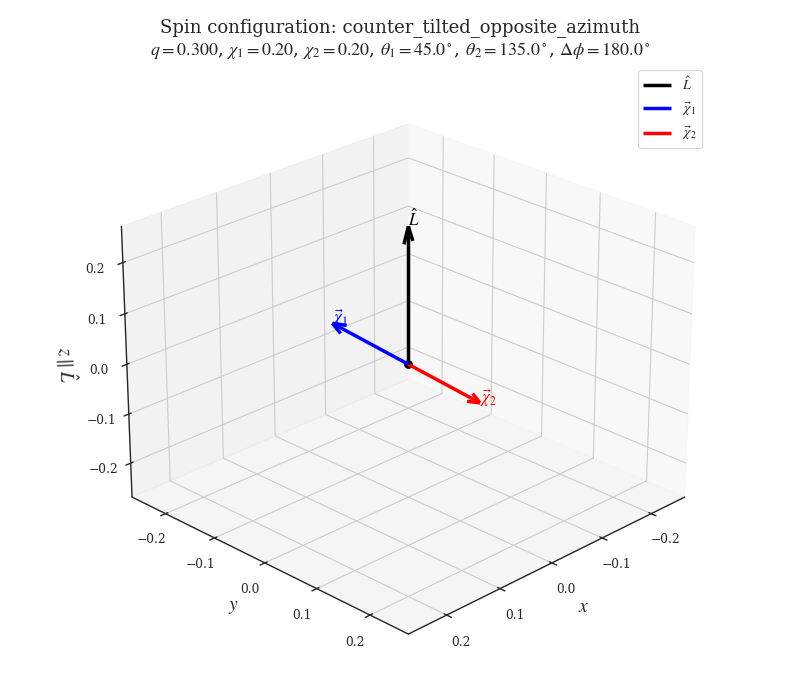

In [169]:
campaign_db_path = Path("/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/""bbh_precession_campaign/bbh_lowq_precession_campaign.sqlite")
conn = sqlite3.connect(campaign_db_path)
catalog_df = pd.read_sql_query("SELECT * FROM catalog",conn)
display(catalog_df[["spin_geometry", "category", "priority", "theta1_deg", "theta2_deg", "dphi_deg"]].drop_duplicates().sort_values(["priority", "category", "spin_geometry"]).reset_index(drop=True))

target_q = 0.3
target_chi1 = 0.20
target_chi2 = 0.20
target_spin_geometry = "counter_tilted_opposite_azimuth"

mask = ((catalog_df["status"] == "simulated")& np.isclose(catalog_df["q"], target_q)& np.isclose(catalog_df["chi1"], target_chi1)& np.isclose(catalog_df["chi2"], target_chi2)& (catalog_df["spin_geometry"] == target_spin_geometry))
matching_configs = catalog_df[mask].copy().reset_index(drop=True)

if len(matching_configs) == 0:
    conn.close()
    raise ValueError("No configuration found")

selected_config = matching_configs.iloc[0]
config_id = selected_config["config_id"]
df_evol = pd.read_sql_query("SELECT * FROM evolutions WHERE config_id = ?",conn,params=(config_id,))
conn.close()

if len(df_evol) == 0:
    raise ValueError(f"No evolution found")


q_prec = float(selected_config["q"])

m1 = float(selected_config["m1"])
m2 = float(selected_config["m2"])
chi1 = float(selected_config["chi1"])
chi2 = float(selected_config["chi2"])
theta1_0 = float(selected_config["theta1_rad"])
theta2_0 = float(selected_config["theta2_rad"])
dphi_0 = float(selected_config["dphi_rad"])
theta1_0_deg = float(selected_config["theta1_deg"])
theta2_0_deg = float(selected_config["theta2_deg"])
dphi_0_deg = float(selected_config["dphi_deg"])
spin_geometry = selected_config["spin_geometry"]
category = selected_config["category"]
priority = selected_config["priority"]

print()
print("Physical parameters:")
print(f"config_id      = {config_id}")
print(f"q_prec         = {q_prec}")
print(f"m1             = {m1}")
print(f"m2             = {m2}")
print(f"chi1           = {chi1}")
print(f"chi2           = {chi2}")
print(f"theta1_0       = {theta1_0_deg:.3f} deg")
print(f"theta2_0       = {theta2_0_deg:.3f} deg")
print(f"dphi_0         = {dphi_0_deg:.3f} deg")
print(f"spin_geometry  = {spin_geometry}")
print(f"category       = {category}")
print(f"priority       = {priority}")



def get_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return df[name].to_numpy(dtype=float), name
    raise KeyError(
        "None of these columns were found")

a_prec, a_col = get_column(df_evol,["a", "separation", "r"])
th1, th1_col = get_column(df_evol,["theta1", "th1", "theta_1", "theta1_0", "theta1_0_rad"])
th2, th2_col = get_column(df_evol,["theta2", "th2", "theta_2", "theta2_0", "theta2_0_rad"])
dphi, dphi_col = get_column(df_evol,["deltaphi", "dphi", "delta_phi", "DeltaPhi", "dphi_0", "dphi_0_rad"])




def spin_cartesian(chi, theta, phi):
    x = chi * np.sin(theta) * np.cos(phi)
    y = chi * np.sin(theta) * np.sin(phi)
    z = chi * np.cos(theta)

    return np.array([x, y, z], dtype=float)

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_mid = np.mean(x_limits)
    y_mid = np.mean(y_limits)
    z_mid = np.mean(z_limits)

    ax.set_xlim3d([x_mid - max_range / 2, x_mid + max_range / 2])
    ax.set_ylim3d([y_mid - max_range / 2, y_mid + max_range / 2])
    ax.set_zlim3d([z_mid - max_range / 2, z_mid + max_range / 2])

phi1_0 = 0.0
phi2_0 = dphi_0
chi1_vec = spin_cartesian(chi1, theta1_0, phi1_0)
chi2_vec = spin_cartesian(chi2, theta2_0, phi2_0)
Lhat_vec = np.array([0.0, 0.0, 1.0])
max_val = max(chi1, chi2)
axis_limit = 1.35 * max_val

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(0, 0, 0, color="black", s=30)
ax.quiver(
    0, 0, 0,
    0, 0, axis_limit,
    color="black",
    linewidth=2.5,
    arrow_length_ratio=0.12,
    label=r"$\hat{L}$"
)
ax.quiver(
    0, 0, 0,
    chi1_vec[0], chi1_vec[1], chi1_vec[2],
    color="blue",
    linewidth=2.5,
    arrow_length_ratio=0.15,
    label=r"$\vec{\chi}_1$"
)
ax.quiver(
    0, 0, 0,
    chi2_vec[0], chi2_vec[1], chi2_vec[2],
    color="red",
    linewidth=2.5,
    arrow_length_ratio=0.15,
    label=r"$\vec{\chi}_2$"
)

ax.text(0, 0, axis_limit, r"$\hat{L}$", color="black")
ax.text(chi1_vec[0], chi1_vec[1], chi1_vec[2], r"$\vec{\chi}_1$", color="blue")
ax.text(chi2_vec[0], chi2_vec[1], chi2_vec[2], r"$\vec{\chi}_2$", color="red")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z \parallel \hat{L}$")
ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)
ax.set_zlim(-axis_limit, axis_limit)
set_axes_equal(ax)
ax.set_title(
    rf"Spin configuration: {spin_geometry}"
    "\n"
    rf"$q={q_prec:.3f}$, "
    rf"$\chi_1={chi1:.2f}$, "
    rf"$\chi_2={chi2:.2f}$, "
    rf"$\theta_1={theta1_0_deg:.1f}^\circ$, "
    rf"$\theta_2={theta2_0_deg:.1f}^\circ$, "
    rf"$\Delta\phi={dphi_0_deg:.1f}^\circ$"
)
ax.legend()
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

In [170]:
def interpolate_at_separation(a_array, y_array, a_ref):
    a_array = np.asarray(a_array, dtype=float)
    y_array = np.asarray(y_array, dtype=float)
    valid = np.isfinite(a_array) & np.isfinite(y_array)
    a_valid = a_array[valid]
    y_valid = y_array[valid]
    sort_idx = np.argsort(a_valid)
    a_sorted = a_valid[sort_idx]
    y_sorted = y_valid[sort_idx]

    if a_ref < a_sorted[0] or a_ref > a_sorted[-1]:
        raise ValueError(
            f"a_ref = {a_ref:.8f} is outside the available precession range "
            f"[{a_sorted[0]:.8f}, {a_sorted[-1]:.8f}]."
        )

    return np.interp(a_ref, a_sorted, y_sorted)

def build_spin_vectors_from_angles(chi1, chi2, theta1, theta2, dphi):
    phi1 = 0.0
    phi2 = phi1 + dphi
    chi1_vec = np.array([
        chi1 * np.sin(theta1) * np.cos(phi1),
        chi1 * np.sin(theta1) * np.sin(phi1),
        chi1 * np.cos(theta1)
    ])
    chi2_vec = np.array([
        chi2 * np.sin(theta2) * np.cos(phi2),
        chi2 * np.sin(theta2) * np.sin(phi2),
        chi2 * np.cos(theta2)
    ])

    return chi1_vec, chi2_vec

def extract_merger_from_waveform(t, h, peak_window=5):
    h22 = h[(2, 2)]
    amp22 = np.abs(h22)
    idx_peak = int(np.nanargmax(amp22))
    phase22 = np.unwrap(np.angle(h22))
    omega22 = np.abs(np.gradient(phase22, t))
    omega_orb = omega22 / 2.0
    a_inst = np.maximum(omega_orb, 1.0e-12)**(-2.0 / 3.0)
    i_min = max(0, idx_peak - peak_window)
    i_max = min(len(t), idx_peak + peak_window + 1)
    a_merger = np.nanmedian(a_inst[i_min:i_max])

    return a_merger, a_inst, idx_peak

def get_merger_separation_NR_adaptive_fref(
    q_surr,
    chi1,
    chi2,
    a_prec,
    th1,
    th2,
    dphi,
    omega_ref_start=0.0195,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5
):
    q_surr = float(q_surr)

    if q_surr < 1.0:
        raise ValueError("q_surr must satisfy q_surr >= 1.")

    dphi_unwrapped = np.unwrap(dphi)

    last_error = None

    for attempt in range(max_attempts):

        omega_ref = omega_ref_start * omega_ref_factor**attempt
        f_ref = omega_ref / np.pi

        a_ref = omega_ref**(-2.0 / 3.0)

        try:
            theta1_ref = interpolate_at_separation(a_prec, th1, a_ref)
            theta2_ref = interpolate_at_separation(a_prec, th2, a_ref)

            dphi_ref = interpolate_at_separation(
                a_prec,
                dphi_unwrapped,
                a_ref
            )

            dphi_ref = (dphi_ref + np.pi) % (2.0 * np.pi) - np.pi

            chi1_ref_vec, chi2_ref_vec = build_spin_vectors_from_angles(
                chi1=chi1,
                chi2=chi2,
                theta1=theta1_ref,
                theta2=theta2_ref,
                dphi=dphi_ref
            )

            t, h, _ = sur_wave_precessing(
                q_surr,
                chi1_ref_vec,
                chi2_ref_vec,
                dt=dt,
                f_low=f_low,
                f_ref=f_ref
            )

            a_merger, a_inst, idx_peak = extract_merger_from_waveform(
                t,
                h,
                peak_window=peak_window
            )

            return {
                "a_merger": a_merger,
                "t_surr": t,
                "a_inst": a_inst,
                "idx_peak": idx_peak,
                "omega_ref": omega_ref,
                "f_ref": f_ref,
                "a_ref": a_ref,
                "theta1_ref": theta1_ref,
                "theta2_ref": theta2_ref,
                "dphi_ref": dphi_ref,
                "chi1_ref_vec": chi1_ref_vec,
                "chi2_ref_vec": chi2_ref_vec,
                "attempt": attempt,
            }

        except Exception as exc:
            last_error = exc

            error_message = str(exc)

            if "too small" in error_message or "omega_ref" in error_message:
                continue

            raise exc

    raise RuntimeError(
        "Could not find a valid f_ref for the waveform surrogate.\n"
        f"Last error was:\n{repr(last_error)}"
    )

q_surr = 1.0 / q_prec
nr_result = get_merger_separation_NR_adaptive_fref(
    q_surr=q_surr,
    chi1=chi1,
    chi2=chi2,
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    omega_ref_start=0.0195,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5
)

a_merger = nr_result["a_merger"]
t_surr = nr_result["t_surr"]
a_inst = nr_result["a_inst"]

chi1_ref_vec = nr_result["chi1_ref_vec"]
chi2_ref_vec = nr_result["chi2_ref_vec"]

omega_ref_surrogate = nr_result["omega_ref"]
f_ref_surrogate = nr_result["f_ref"]
a_ref_surrogate = nr_result["a_ref"]

theta1_ref = nr_result["theta1_ref"]
theta2_ref = nr_result["theta2_ref"]
dphi_ref = nr_result["dphi_ref"]

mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(
    q_surr,
    chi1_ref_vec,
    chi2_ref_vec
)

chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)

print()
print("NR/surrogate merger estimate:")
print(f"a_merger = {a_merger:.8f}")


NR/surrogate merger estimate:
a_merger = 3.38026806


In [171]:
out_0PN = get_0PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

out_1PN = get_1PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

out_2PN = get_2PN_precessing_2(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True,
)

E_tot_0PN = out_0PN["E_tot"]
E_bind_0PN = out_0PN["E_bind"]
J_tot_0PN = out_0PN["J_tot"]
J_vec_0PN = out_0PN["J_vec"]
L_orb_0PN = out_0PN["L_orb"]

E_tot_1PN = out_1PN["E_tot"]
E_bind_1PN = out_1PN["E_bind"]
J_tot_1PN = out_1PN["J_tot"]
J_vec_1PN = out_1PN["J_vec"]
L_orb_1PN = out_1PN["L_orb"]

E_tot_2PN = out_2PN["E_tot"]
E_bind_2PN = out_2PN["E_bind"]
J_tot_2PN = out_2PN["J_tot"]
J_vec_2PN = out_2PN["J_vec"]
L_vec_2PN = out_2PN["L_vec"]

ENT_0PN = entropy(E_tot_0PN, J_tot_0PN)
ENT_1PN = entropy(E_tot_1PN, J_tot_1PN)
ENT_2PN = entropy(E_tot_2PN, J_tot_2PN)

Saving Images

In [ ]:
figure_data_dir = Path("data/final_results/figures")
figure_data_dir.mkdir(parents=True, exist_ok=True)

overwrite_existing_figures = True

def get_optional_variable(name, default=np.nan):
    return globals().get(name, default)

def format_value_for_title(value, ndigits=3):
    try:
        value = float(value)

        if np.isfinite(value):
            return f"{value:.{ndigits}f}"

        return "nan"

    except Exception:
        return "nan"

def safe_filename(text):
    text = str(text)

    replacements = {
        "é": "e",
        "è": "e",
        "à": "a",
        "ò": "o",
        "ù": "u",
        "ì": "i",
        "Δ": "Delta",
        "φ": "phi",
        "χ": "chi",
        "θ": "theta",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    text = re.sub(r"_+", "_", text)

    return text.strip("_")

def resolve_dphi_deg():


    possible_names = [
        "deltaphi_0_deg",
        "deltaphi_deg",
        "delta_phi_0_deg",
        "delta_phi_deg",
        "DeltaPhi_0_deg",
        "DeltaPhi_deg",
        "dphi_0_deg",
        "dphi_deg",
        "target_dphi_deg",
        "target_deltaphi_deg",
        "target_delta_phi_deg",
    ]

    for name in possible_names:
        if name in globals():
            try:
                value = float(globals()[name])

                if np.isfinite(value):
                    return value

            except Exception:
                pass


    if "matching_configs" in globals():
        try:
            for col in possible_names:
                if col in matching_configs.columns:
                    value = float(matching_configs.iloc[0][col])

                    if np.isfinite(value):
                        return value

        except Exception:
            pass


    for obj_name in ["selected_config", "config_row", "current_config"]:
        if obj_name in globals():
            try:
                obj = globals()[obj_name]

                for col in possible_names:
                    if col in obj:
                        value = float(obj[col])

                        if np.isfinite(value):
                            return value

            except Exception:
                pass


    configuration_name_value = str(
        globals().get("configuration_name", "")
    ).lower()

    spin_geometry_value = str(
        globals().get(
            "target_spin_geometry",
            globals().get("spin_geometry", "")
        )
    ).lower()

    combined_label = configuration_name_value + "_" + spin_geometry_value

    if "same_plane" in combined_label:
        return 0.0

    if "opposite" in combined_label:
        return 180.0

    if "aligned" in combined_label or "antialigned" in combined_label:
        return 0.0

    return np.nan


deltaphi_0_deg = resolve_dphi_deg()
dphi_deg = deltaphi_0_deg

print(f"Resolved Delta phi = {deltaphi_0_deg:.3f} deg")

def get_current_configuration_title():
    q_value = get_optional_variable(
        "q_prec",
        get_optional_variable("target_q", np.nan)
    )

    chi1_value = get_optional_variable(
        "chi1",
        get_optional_variable("target_chi1", np.nan)
    )

    chi2_value = get_optional_variable(
        "chi2",
        get_optional_variable("target_chi2", np.nan)
    )

    theta1_value = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    theta2_value = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    dphi_value = resolve_dphi_deg()

    spin_geometry_value = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "")
    )

    configuration_name_value = get_optional_variable(
        "configuration_name",
        ""
    )

    if isinstance(configuration_name_value, str) and configuration_name_value.strip() != "":
        config_label = configuration_name_value.strip()

    elif isinstance(spin_geometry_value, str) and spin_geometry_value.strip() != "":
        config_label = spin_geometry_value.strip()

    else:
        config_label = "Current configuration"

    title = (
        rf"{config_label}"
        "\n"
        rf"$q={format_value_for_title(q_value, 3)}$, "
        rf"$\chi_1={format_value_for_title(chi1_value, 3)}$, "
        rf"$\chi_2={format_value_for_title(chi2_value, 3)}$, "
        rf"$\theta_1={format_value_for_title(theta1_value, 2)}^\circ$, "
        rf"$\theta_2={format_value_for_title(theta2_value, 2)}^\circ$, "
        rf"$\Delta\phi={format_value_for_title(dphi_value, 2)}^\circ$"
    )

    return title

def get_current_configuration_filename():
    configuration_name_value = get_optional_variable(
        "configuration_name",
        ""
    )

    if isinstance(configuration_name_value, str) and configuration_name_value.strip() != "":
        return safe_filename(configuration_name_value.strip())

    spin_geometry_value = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "config")
    )

    q_value = get_optional_variable(
        "q_prec",
        get_optional_variable("target_q", np.nan)
    )

    chi1_value = get_optional_variable(
        "chi1",
        get_optional_variable("target_chi1", np.nan)
    )

    chi2_value = get_optional_variable(
        "chi2",
        get_optional_variable("target_chi2", np.nan)
    )

    theta1_value = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    theta2_value = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    dphi_value = resolve_dphi_deg()

    name = (
        f"{spin_geometry_value}_"
        f"q{float(q_value):.4g}_"
        f"chi1{float(chi1_value):.3g}_"
        f"chi2{float(chi2_value):.3g}_"
        f"th1{float(theta1_value):.3g}_"
        f"th2{float(theta2_value):.3g}_"
        f"dphi{float(dphi_value):.3g}"
    )

    return safe_filename(name)

def save_current_figure(fig, method_label):

    config_name = get_current_configuration_filename()
    method_label = safe_filename(method_label)

    png_path = figure_data_dir / f"{config_name}_{method_label}_entropy_curves.png"

    if png_path.exists() and not overwrite_existing_figures:
        print("Figure already exists. No file overwritten:")
        print(f"  {png_path.resolve()}")
        return png_path

    fig.savefig(
        png_path,
        dpi=180,
        bbox_inches="tight",
        pad_inches=0.04,
        facecolor="white"
    )

    print("Saved figure:")
    print(f"  {png_path.resolve()}")

    return png_path

Resolved Delta phi = 0.000 deg


PADE'

In [179]:
def fit_pade_2_1(
    x,
    y,
    sigma,
    y_scale=None,
    n_starts=10,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label="Padé [2/1] fit"
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if len(x) < 10:
        raise RuntimeError(f"Too few valid points for {progress_label}: {len(x)}")

    if y_scale is None or not np.isfinite(y_scale) or y_scale == 0.0:
        y_scale = 1.0

    lower_bounds = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds = np.array([np.inf, np.inf, np.inf, np.inf], dtype=float)

    def residuals(params):
        y_model = pade_2_1(x, *params)
        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)
        return res

    rng = np.random.default_rng(random_seed)

    starts = [
        np.array(
            [
                np.nanmedian(y),
                0.0,
                0.0,
                0.1
            ],
            dtype=float
        )
    ]

    for _ in range(n_starts - 1):
        starts.append(
            np.array(
                [
                    np.nanmedian(y),
                    rng.normal(loc=0.0, scale=0.2 * y_scale),
                    rng.normal(loc=0.0, scale=0.2 * y_scale),
                    rng.uniform(low=0.0, high=1.0)
                ],
                dtype=float
            )
        )

    best_result = None
    best_cost = np.inf
    last_exception = None

    iterator = tqdm(
        starts,
        desc=progress_label,
        total=len(starts),
        leave=True
    )

    for p0 in iterator:
        try:
            result = least_squares(
                residuals,
                p0,
                bounds=(lower_bounds, upper_bounds),
                loss=loss,
                f_scale=f_scale,
                x_scale="jac",
                max_nfev=max_nfev
            )

            if result.success and np.isfinite(result.cost) and result.cost < best_cost:
                best_result = result
                best_cost = result.cost

            iterator.set_postfix(best_cost=f"{best_cost:.3e}")

        except Exception as exc:
            last_exception = exc
            iterator.set_postfix(error=str(exc)[:40])
            continue

    if best_result is None:
        raise RuntimeError(
            "Padé [2/1] fit failed.\n"
            f"Last exception: {repr(last_exception)}"
        )

    return best_result.x, best_result

def run_pade_entropy_extrapolation(
    pn_label,
    a_arr,
    M_arr,
    J_arr,
    S_arr,
    m_ref,
    a_merger,
    a_extrap_max=15.0,
    a_extrap_min=1.0,
    n_extrap=10000,
    sigma_power=3.0,
    n_starts_Ebind=10,
    n_starts_chi=10
):
    a_arr = np.asarray(a_arr, dtype=float)
    M_arr = np.asarray(M_arr, dtype=float)
    J_arr = np.asarray(J_arr, dtype=float)
    S_arr = np.asarray(S_arr, dtype=float)

    valid_mask = (
        np.isfinite(S_arr)
        & np.isfinite(a_arr)
        & np.isfinite(M_arr)
        & np.isfinite(J_arr)
        & (a_arr > 0)
        & (M_arr > 0)
    )

    a_valid = a_arr[valid_mask]
    M_valid = M_arr[valid_mask]
    J_valid = J_arr[valid_mask]
    S_valid = S_arr[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_fit = a_valid[sort_idx]
    M_fit = M_valid[sort_idx]
    J_fit = J_valid[sort_idx]
    S_fit = S_valid[sort_idx]

    x_fit = 1.0 / np.sqrt(a_fit)

    Ebind_fit = M_fit - m_ref
    chi_fit = J_fit / M_fit**2

    fit_mask = (
        np.isfinite(x_fit)
        & np.isfinite(Ebind_fit)
        & np.isfinite(chi_fit)
        & (np.abs(chi_fit) <= 1.0)
    )

    a_fit = a_fit[fit_mask]
    x_fit = x_fit[fit_mask]
    M_fit = M_fit[fit_mask]
    J_fit = J_fit[fit_mask]
    S_fit = S_fit[fit_mask]
    Ebind_fit = Ebind_fit[fit_mask]
    chi_fit = chi_fit[fit_mask]

    if len(x_fit) < 10:
        raise RuntimeError(f"Too few valid points for {pn_label}: {len(x_fit)}")

    a_min_fit = np.nanmin(a_fit)
    sigma_fit = (a_fit / a_min_fit)**sigma_power

    popt_Ebind, result_Ebind = fit_pade_2_1(
        x=x_fit,
        y=Ebind_fit,
        sigma=sigma_fit,
        y_scale=np.nanstd(Ebind_fit),
        n_starts=n_starts_Ebind,
        random_seed=1234,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=30000,
        progress_label=fr"{pn_label}: fitting $E_{{\rm bind}}$"
    )

    popt_chi, result_chi = fit_pade_2_1(
        x=x_fit,
        y=chi_fit,
        sigma=sigma_fit,
        y_scale=np.nanstd(chi_fit),
        n_starts=n_starts_chi,
        random_seed=4321,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=15000,
        progress_label=fr"{pn_label}: fitting $\chi$"
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    x_extrap = 1.0 / np.sqrt(a_extrap)

    Ebind_extrap = pade_2_1(x_extrap, *popt_Ebind)
    chi_extrap = pade_2_1(x_extrap, *popt_chi)

    M_extrap = m_ref + Ebind_extrap
    J_extrap = chi_extrap * M_extrap**2

    physical_mask = (
        np.isfinite(M_extrap)
        & np.isfinite(chi_extrap)
        & np.isfinite(J_extrap)
        & (M_extrap > 0)
        & (np.abs(chi_extrap) <= 1.0)
        & (np.abs(J_extrap) <= M_extrap**2)
    )

    ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

    ENT_extrap[physical_mask] = entropy(
        M_extrap[physical_mask],
        J_extrap[physical_mask]
    )

    if np.all(np.isnan(ENT_extrap)):
        raise RuntimeError(
            f"The Padé [2/1] extrapolated curve for {pn_label} has no physical points."
        )

    idx_max = np.nanargmax(ENT_extrap)

    a_max_entropy = a_extrap[idx_max]
    S_max_entropy = ENT_extrap[idx_max]
    M_at_max = M_extrap[idx_max]
    J_at_max = J_extrap[idx_max]
    chi_at_max = chi_extrap[idx_max]
    delta_a = np.abs(a_max_entropy - a_merger)

    flags = []

    if idx_max == 0:
        flags.append("maximum_at_upper_boundary")

    if idx_max == len(a_extrap) - 1:
        flags.append("maximum_at_lower_boundary")

    if len(flags) == 0:
        flags.append("OK")

    result_row = {
        "PN_order": pn_label,
        "model": "Padé [2/1]",
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "a_merger_NR": a_merger,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "flags": ", ".join(flags)
    }

    curve_dict = {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "popt_Ebind": popt_Ebind,
        "popt_chi": popt_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask,
        "idx_max": idx_max
    }

    return result_row, curve_dict


try:
    m_ref = float(m1 + m2)
except NameError:
    try:
        m_ref = float(m1 + m2)
    except Exception:
        m_ref = 1.0


pade_inputs = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}


pade_results_all = []
pade_curves_all = {}

for pn_label, data in pade_inputs.items():
    result_row, curve_dict = run_pade_entropy_extrapolation(
        pn_label=pn_label,
        a_arr=data["a"],
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        a_extrap_max=50.0,
        a_extrap_min=2.0,
        n_extrap=100000,
        sigma_power=2.0,
        n_starts_Ebind=5,
        n_starts_chi=5
    )

    pade_results_all.append(result_row)
    pade_curves_all[pn_label] = curve_dict


results_pade_all_df = pd.DataFrame(pade_results_all)

print("============================================================")
print("PADÉ [2/1] EXTRAPOLATION")
print("============================================================")

for _, row in results_pade_all_df.iterrows():
    print(f"{row['PN_order']}  {row['model']}")
    print(f"  a_max      = {row['a_max']:.6f}")
    print(f"  a_merger   = {row['a_merger_NR']:.6f}")
    print(f"  Delta a    = {row['delta_a']:.6f}")
    print(f"  flags      = {row['flags']}")
    print("------------------------------------------------------------")

0PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

0PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

1PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

1PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

2PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

2PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

PADÉ [2/1] EXTRAPOLATION
0PN  Padé [2/1]
  a_max      = 4.026580
  a_merger   = 3.380268
  Delta a    = 0.646312
  flags      = OK
------------------------------------------------------------
1PN  Padé [2/1]
  a_max      = 3.285453
  a_merger   = 3.380268
  Delta a    = 0.094815
  flags      = OK
------------------------------------------------------------
2PN  Padé [2/1]
  a_max      = 3.861459
  a_merger   = 3.380268
  Delta a    = 0.481191
  flags      = OK
------------------------------------------------------------


Saved figure:
  data/final_results/figures/counter_tilted_opposite_azimuth_q0.3_chi10.2_chi20.2_th145_th2135_dphi0_pade_entropy_curves.png
  data/final_results/figures/counter_tilted_opposite_azimuth_q0.3_chi10.2_chi20.2_th145_th2135_dphi0_pade_entropy_curves.pdf


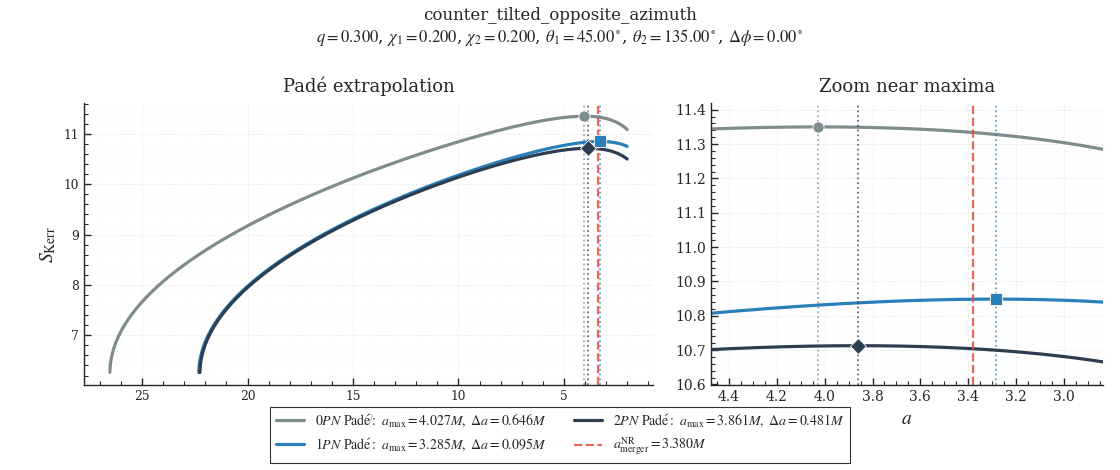

In [180]:
figure_data_dir = Path("data/final_results/figures")
figure_data_dir.mkdir(parents=True, exist_ok=True)

overwrite_existing_figures = True


def get_optional_variable(name, default=np.nan):
    return globals().get(name, default)

def format_value_for_title(value, ndigits=3):
    try:
        value = float(value)
        if np.isfinite(value):
            return f"{value:.{ndigits}f}"
        return "nan"
    except Exception:
        return "nan"

def safe_filename(text):
    text = str(text)
    text = text.replace("é", "e").replace("è", "e").replace("à", "a")
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")

def resolve_dphi_deg():
    possible_names = [
        "deltaphi_0_deg",
        "deltaphi_deg",
        "delta_phi_0_deg",
        "delta_phi_deg",
        "DeltaPhi_0_deg",
        "DeltaPhi_deg",
        "dphi_0_deg",
        "dphi_deg",
        "target_dphi_deg",
        "target_deltaphi_deg",
        "target_delta_phi_deg",
    ]

    for name in possible_names:
        if name in globals():
            try:
                value = float(globals()[name])
                if np.isfinite(value):
                    return value
            except Exception:
                pass

    if "matching_configs" in globals():
        try:
            for col in possible_names:
                if col in matching_configs.columns:
                    value = float(matching_configs.iloc[0][col])
                    if np.isfinite(value):
                        return value
        except Exception:
            pass

    for obj_name in ["selected_config", "config_row", "current_config"]:
        if obj_name in globals():
            try:
                obj = globals()[obj_name]
                for col in possible_names:
                    if col in obj:
                        value = float(obj[col])
                        if np.isfinite(value):
                            return value
            except Exception:
                pass

    configuration_name_value = str(
        globals().get("configuration_name", "")
    ).lower()

    spin_geometry_value = str(
        globals().get(
            "target_spin_geometry",
            globals().get("spin_geometry", "")
        )
    ).lower()

    combined_label = configuration_name_value + "_" + spin_geometry_value

    if "same_plane" in combined_label:
        return 0.0

    if "opposite" in combined_label:
        return 180.0

    if "aligned" in combined_label or "antialigned" in combined_label:
        return 0.0

    return np.nan

deltaphi_0_deg = resolve_dphi_deg()
dphi_deg = deltaphi_0_deg

def get_current_configuration_title():
    q_value = get_optional_variable(
        "q_prec",
        get_optional_variable("target_q", np.nan)
    )

    chi1_value = get_optional_variable(
        "chi1",
        get_optional_variable("target_chi1", np.nan)
    )

    chi2_value = get_optional_variable(
        "chi2",
        get_optional_variable("target_chi2", np.nan)
    )

    theta1_value = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    theta2_value = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    dphi_value = resolve_dphi_deg()

    spin_geometry_value = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "")
    )

    configuration_name_value = get_optional_variable(
        "configuration_name",
        ""
    )

    if isinstance(configuration_name_value, str) and configuration_name_value.strip() != "":
        config_label = configuration_name_value.strip()
    elif isinstance(spin_geometry_value, str) and spin_geometry_value.strip() != "":
        config_label = spin_geometry_value.strip()
    else:
        config_label = "Current configuration"

    title = (
        rf"{config_label}"
        "\n"
        rf"$q={format_value_for_title(q_value, 3)}$, "
        rf"$\chi_1={format_value_for_title(chi1_value, 3)}$, "
        rf"$\chi_2={format_value_for_title(chi2_value, 3)}$, "
        rf"$\theta_1={format_value_for_title(theta1_value, 2)}^\circ$, "
        rf"$\theta_2={format_value_for_title(theta2_value, 2)}^\circ$, "
        rf"$\Delta\phi={format_value_for_title(dphi_value, 2)}^\circ$"
    )

    return title

def get_current_configuration_filename():
    configuration_name_value = get_optional_variable(
        "configuration_name",
        ""
    )

    if isinstance(configuration_name_value, str) and configuration_name_value.strip() != "":
        return safe_filename(configuration_name_value.strip())

    spin_geometry_value = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "config")
    )

    q_value = get_optional_variable("q_prec", get_optional_variable("target_q", np.nan))
    chi1_value = get_optional_variable("chi1", get_optional_variable("target_chi1", np.nan))
    chi2_value = get_optional_variable("chi2", get_optional_variable("target_chi2", np.nan))
    theta1_value = get_optional_variable("theta1_0_deg", get_optional_variable("target_theta1_deg", np.nan))
    theta2_value = get_optional_variable("theta2_0_deg", get_optional_variable("target_theta2_deg", np.nan))
    dphi_value = resolve_dphi_deg()

    name = (
        f"{spin_geometry_value}_"
        f"q{float(q_value):.4g}_"
        f"chi1{float(chi1_value):.3g}_"
        f"chi2{float(chi2_value):.3g}_"
        f"th1{float(theta1_value):.3g}_"
        f"th2{float(theta2_value):.3g}_"
        f"dphi{float(dphi_value):.3g}"
    )

    return safe_filename(name)

def save_current_figure(fig, method_label):
    config_name = get_current_configuration_filename()
    method_label = safe_filename(method_label)

    png_path = figure_data_dir / f"{config_name}_{method_label}_entropy_curves.png"
    pdf_path = figure_data_dir / f"{config_name}_{method_label}_entropy_curves.pdf"

    if (png_path.exists() or pdf_path.exists()) and not overwrite_existing_figures:
        print("Figure already exists. No file overwritten:")
        print(f"  {png_path}")
        print(f"  {pdf_path}")
        return

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print("Saved figure:")
    print(f"  {png_path}")
    print(f"  {pdf_path}")


sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

colors = {
    "0PN": "#7f8c8d",
    "1PN": "#2980b9",
    "2PN": "#2c3e50",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.7),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

fig.suptitle(
    get_current_configuration_title(),
    fontsize=12,
    y=0.985
)

curve_data = {}
focus_a_values = [a_merger]

for pn_label in pn_labels:

    curve = pade_curves_all[pn_label]

    row = results_pade_all_df.loc[
        results_pade_all_df["PN_order"].astype(str) == pn_label
    ].iloc[0]

    a_extrap_i = np.asarray(curve["a_extrap"], dtype=float)
    ENT_extrap_i = np.asarray(curve["ENT_extrap"], dtype=float)

    a_max_i = float(row["a_max"])
    delta_a_i = float(row["delta_a"])

    sort_idx_i = np.argsort(a_extrap_i)
    a_sorted_i = a_extrap_i[sort_idx_i]
    ent_sorted_i = ENT_extrap_i[sort_idx_i]

    valid_i = np.isfinite(a_sorted_i) & np.isfinite(ent_sorted_i)

    a_sorted_valid = a_sorted_i[valid_i]
    ent_sorted_valid = ent_sorted_i[valid_i]

    y_at_max_i = np.interp(
        a_max_i,
        a_sorted_valid,
        ent_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_extrap_i,
        "ent": ENT_extrap_i,
        "a_sorted_valid": a_sorted_valid,
        "ent_sorted_valid": ent_sorted_valid,
        "a_max": a_max_i,
        "y_max": y_at_max_i,
        "delta_a": delta_a_i,
    }

    focus_a_values.append(a_max_i)

    label_i = (
        fr"${pn_label}\ \mathrm{{Pad\acute{{e}}}}:\ "
        fr"a_{{\max}}={a_max_i:.3f}M,\ "
        fr"\Delta a={delta_a_i:.3f}M$"
    )

    ax.plot(
        a_extrap_i,
        ENT_extrap_i,
        color=colors[pn_label],
        lw=2.3,
        label=label_i
    )

    ax.scatter(
        a_max_i,
        y_at_max_i,
        marker=markers[pn_label],
        s=65,
        color=colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_max_i,
        color=colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.75
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.85,
    label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.set_title(r"Padé extrapolation", pad=8)

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:
    a_vals = curve_data[pn_label]["a_sorted_valid"]
    ent_vals = curve_data[pn_label]["ent_sorted_valid"]

    focus_mask = (a_vals >= x_low) & (a_vals <= x_high)
    y_focus_values.extend(ent_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)
y_focus_values = y_focus_values[np.isfinite(y_focus_values)]

if len(y_focus_values) == 0:
    y_focus_values = []

    for pn_label in pn_labels:
        ent_vals = curve_data[pn_label]["ent_sorted_valid"]
        y_focus_values.extend(ent_vals[np.isfinite(ent_vals)])

    y_focus_values = np.asarray(y_focus_values, dtype=float)

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)
y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["ent"],
        color=colors[pn_label],
        lw=2.3
    )

    axz.scatter(
        curve_data[pn_label]["a_max"],
        curve_data[pn_label]["y_max"],
        marker=markers[pn_label],
        s=65,
        color=colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_max"],
        color=colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.75
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.85
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a$")
axz.set_title("Zoom near maxima", pad=8)
axz.tick_params(axis="both", labelsize=10)

for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    axis.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=2,
    borderaxespad=0.0
)

sns.despine()

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.18,
    top=0.78,
    wspace=0.12
)

save_current_figure(
    fig,
    method_label="pade"
)

plt.show()

TAYLOR

In [181]:
def taylor_model_scaled(x, coeffs, x_center, x_scale):
    x = np.asarray(x, dtype=float)
    z = (x - x_center) / x_scale
    y = np.zeros_like(z, dtype=float)
    for k, ck in enumerate(coeffs):
        y += ck * z**k
    return y

def fit_taylor_scaled(
    x,
    y,
    sigma,
    degree=3,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=50000,
    progress_label="Taylor fit"
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if len(x) <= degree + 1:
        raise RuntimeError(
            f"Not enough points for Taylor degree {degree}: n_points = {len(x)}."
        )

    x_center = np.nanmean(x)
    x_scale = np.nanstd(x)

    if not np.isfinite(x_scale) or x_scale == 0.0:
        x_scale = 1.0

    z = (x - x_center) / x_scale

    poly_coeff_high_to_low = np.polyfit(
        z,
        y,
        deg=degree,
        w=1.0 / sigma
    )

    p0 = poly_coeff_high_to_low[::-1]

    def residuals(coeffs):
        y_model = taylor_model_scaled(
            x,
            coeffs,
            x_center=x_center,
            x_scale=x_scale
        )

        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)

        return res

    result = least_squares(
        residuals,
        p0,
        loss=loss,
        f_scale=f_scale,
        x_scale="jac",
        max_nfev=max_nfev
    )

    if not result.success:
        raise RuntimeError(
            f"{progress_label} failed: {result.message}"
        )

    return result.x, x_center, x_scale, result

def run_taylor_entropy_extrapolation(
    pn_label,
    a_arr,
    M_arr,
    J_arr,
    S_arr,
    m_ref,
    a_merger,
    degree_Ebind=3,
    degree_chi=3,
    a_extrap_max=15.0,
    a_extrap_min=1.0,
    n_extrap=10000,
    sigma_power=1.0
):
    a_arr = np.asarray(a_arr, dtype=float)
    M_arr = np.asarray(M_arr, dtype=float)
    J_arr = np.asarray(J_arr, dtype=float)
    S_arr = np.asarray(S_arr, dtype=float)

    valid_mask = (
        np.isfinite(S_arr)
        & np.isfinite(a_arr)
        & np.isfinite(M_arr)
        & np.isfinite(J_arr)
        & (a_arr > 0)
        & (M_arr > 0)
    )

    a_valid = a_arr[valid_mask]
    M_valid = M_arr[valid_mask]
    J_valid = J_arr[valid_mask]
    S_valid = S_arr[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_fit = a_valid[sort_idx]
    M_fit = M_valid[sort_idx]
    J_fit = J_valid[sort_idx]
    S_fit = S_valid[sort_idx]

    x_fit = 1.0 / np.sqrt(a_fit)

    Ebind_fit = M_fit - m_ref
    chi_fit = J_fit / M_fit**2

    fit_mask = (
        np.isfinite(x_fit)
        & np.isfinite(Ebind_fit)
        & np.isfinite(chi_fit)
        & (np.abs(chi_fit) <= 1.0)
    )

    a_fit = a_fit[fit_mask]
    x_fit = x_fit[fit_mask]
    M_fit = M_fit[fit_mask]
    J_fit = J_fit[fit_mask]
    S_fit = S_fit[fit_mask]
    Ebind_fit = Ebind_fit[fit_mask]
    chi_fit = chi_fit[fit_mask]

    if len(x_fit) < 20:
        raise RuntimeError(
            f"Too few valid points for a reliable Taylor fit for {pn_label}: {len(x_fit)}"
        )

    a_min_fit = np.nanmin(a_fit)
    sigma_fit = (a_fit / a_min_fit)**sigma_power

    coeff_Ebind, x_center_Ebind, x_scale_Ebind, result_Ebind = fit_taylor_scaled(
        x=x_fit,
        y=Ebind_fit,
        sigma=sigma_fit,
        degree=degree_Ebind,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=30000,
        progress_label=f"{pn_label}: fitting E_bind with Taylor"
    )

    coeff_chi, x_center_chi, x_scale_chi, result_chi = fit_taylor_scaled(
        x=x_fit,
        y=chi_fit,
        sigma=sigma_fit,
        degree=degree_chi,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=15000,
        progress_label=f"{pn_label}: fitting chi with Taylor"
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    x_extrap = 1.0 / np.sqrt(a_extrap)

    Ebind_extrap = taylor_model_scaled(
        x_extrap,
        coeff_Ebind,
        x_center=x_center_Ebind,
        x_scale=x_scale_Ebind
    )

    chi_extrap = taylor_model_scaled(
        x_extrap,
        coeff_chi,
        x_center=x_center_chi,
        x_scale=x_scale_chi
    )

    M_extrap = m_ref + Ebind_extrap
    J_extrap = chi_extrap * M_extrap**2

    physical_mask = (
        np.isfinite(M_extrap)
        & np.isfinite(chi_extrap)
        & np.isfinite(J_extrap)
        & (M_extrap > 0)
        & (np.abs(chi_extrap) <= 1.0)
        & (np.abs(J_extrap) <= M_extrap**2)
    )

    ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

    ENT_extrap[physical_mask] = entropy(
        M_extrap[physical_mask],
        J_extrap[physical_mask]
    )

    if np.all(np.isnan(ENT_extrap)):
        raise RuntimeError(
            f"The Taylor-extrapolated curve for {pn_label} contains no valid physical points."
        )

    idx_max = np.nanargmax(ENT_extrap)

    a_max_entropy = a_extrap[idx_max]
    S_max_entropy = ENT_extrap[idx_max]
    M_at_max = M_extrap[idx_max]
    J_at_max = J_extrap[idx_max]
    chi_at_max = chi_extrap[idx_max]
    delta_a = np.abs(a_max_entropy - a_merger)

    flags = []

    if idx_max == 0:
        flags.append("maximum_at_upper_boundary")

    if idx_max == len(a_extrap) - 1:
        flags.append("maximum_at_lower_boundary")

    if not (np.nanmin(a_extrap) <= a_merger <= np.nanmax(a_extrap)):
        flags.append("a_merger_outside_extrapolation_range")

    if len(flags) == 0:
        flags.append("OK")

    result_row = {
        "PN_order": pn_label,
        "model": f"Taylor degree {degree_Ebind}",
        "degree_Ebind": degree_Ebind,
        "degree_chi": degree_chi,
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "a_merger_NR": a_merger,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "flags": ", ".join(flags)
    }

    curve_dict = {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "coeff_Ebind": coeff_Ebind,
        "coeff_chi": coeff_chi,
        "x_center_Ebind": x_center_Ebind,
        "x_scale_Ebind": x_scale_Ebind,
        "x_center_chi": x_center_chi,
        "x_scale_chi": x_scale_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask,
        "idx_max": idx_max
    }

    return result_row, curve_dict

try:
    m_ref = float(m1 + m2)
except NameError:
    try:
        m_ref = float(m1 + m2)
    except NameError:
        m_ref = 1.0

taylor_inputs = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}

taylor_results_all = []
taylor_curves_all = {}

for pn_label, data in taylor_inputs.items():
    result_row, curve_dict = run_taylor_entropy_extrapolation(
        pn_label=pn_label,
        a_arr=data["a"],
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        degree_Ebind=3,
        degree_chi=3,
        a_extrap_max=15.0,
        a_extrap_min=2.0,
        n_extrap=10000,
        sigma_power=1.0
    )

    taylor_results_all.append(result_row)
    taylor_curves_all[pn_label] = curve_dict

results_taylor_all_df = pd.DataFrame(taylor_results_all)



print("============================================================")
print("TAYLOR EXTRAPOLATION ")
print("============================================================")

for _, row in results_taylor_all_df.iterrows():
    print(f"{row['PN_order']}:")
    print(f"  a_max      = {row['a_max']:.6f}")
    print(f"  a_merger   = {row['a_merger_NR']:.6f}")
    print(f"  Delta a    = {row['delta_a']:.6f}")
    print(f"  flags      = {row['flags']}")
    print("------------------------------------------------------------")

print("============================================================")

TAYLOR EXTRAPOLATION 
0PN:
  a_max      = 3.684968
  a_merger   = 3.380268
  Delta a    = 0.304700
  flags      = OK
------------------------------------------------------------
1PN:
  a_max      = 2.977698
  a_merger   = 3.380268
  Delta a    = 0.402570
  flags      = OK
------------------------------------------------------------
2PN:
  a_max      = 2.913991
  a_merger   = 3.380268
  Delta a    = 0.466277
  flags      = OK
------------------------------------------------------------


Saved figure:
  data/final_results/figures/counter_tilted_opposite_azimuth_q0.3_chi10.2_chi20.2_th145_th2135_dphi0_taylor_entropy_curves.png
  data/final_results/figures/counter_tilted_opposite_azimuth_q0.3_chi10.2_chi20.2_th145_th2135_dphi0_taylor_entropy_curves.pdf


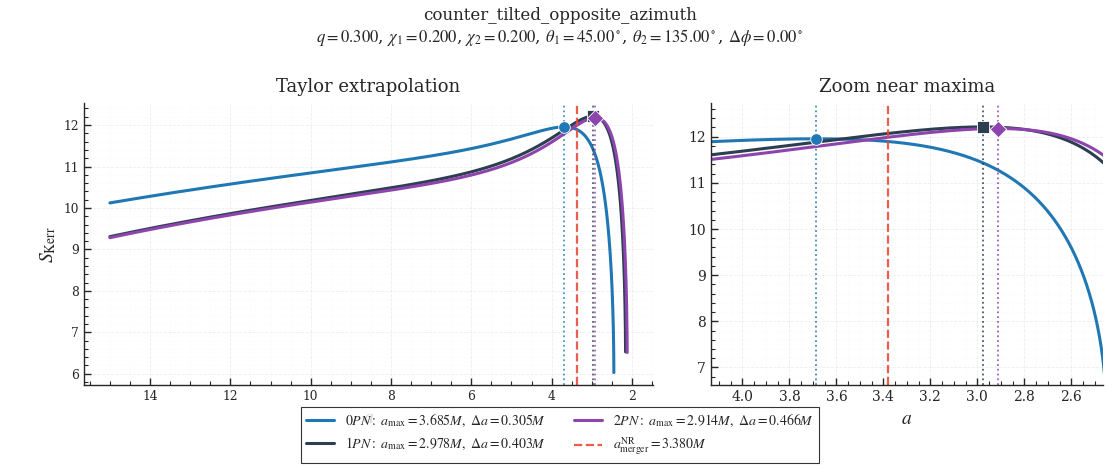

In [182]:
figure_data_dir = Path("data/final_results/figures")
figure_data_dir.mkdir(parents=True, exist_ok=True)

overwrite_existing_figures = True


def get_optional_variable(name, default=np.nan):
    return globals().get(name, default)

def format_value_for_title(value, ndigits=3):
    try:
        value = float(value)
        if np.isfinite(value):
            return f"{value:.{ndigits}f}"
        return "nan"
    except Exception:
        return "nan"

def safe_filename(text):
    text = str(text)
    text = text.replace("é", "e").replace("è", "e").replace("à", "a")
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")

def resolve_dphi_deg():
    possible_names = [
        "deltaphi_0_deg",
        "deltaphi_deg",
        "delta_phi_0_deg",
        "delta_phi_deg",
        "DeltaPhi_0_deg",
        "DeltaPhi_deg",
        "dphi_0_deg",
        "dphi_deg",
        "target_dphi_deg",
        "target_deltaphi_deg",
        "target_delta_phi_deg",
    ]

    # 1. Explicit global variables
    for name in possible_names:
        if name in globals():
            try:
                value = float(globals()[name])
                if np.isfinite(value):
                    return value
            except Exception:
                pass

    # 2. matching_configs dataframe
    if "matching_configs" in globals():
        try:
            for col in possible_names:
                if col in matching_configs.columns:
                    value = float(matching_configs.iloc[0][col])
                    if np.isfinite(value):
                        return value
        except Exception:
            pass

    # 3. Row-like objects
    for obj_name in ["selected_config", "config_row", "current_config"]:
        if obj_name in globals():
            try:
                obj = globals()[obj_name]
                for col in possible_names:
                    if col in obj:
                        value = float(obj[col])
                        if np.isfinite(value):
                            return value
            except Exception:
                pass

    # 4. Fallback from configuration name / geometry
    configuration_name_value = str(
        globals().get("configuration_name", "")
    ).lower()

    spin_geometry_value = str(
        globals().get(
            "target_spin_geometry",
            globals().get("spin_geometry", "")
        )
    ).lower()

    combined_label = configuration_name_value + "_" + spin_geometry_value

    if "same_plane" in combined_label:
        return 0.0

    if "opposite" in combined_label:
        return 180.0

    if "aligned" in combined_label or "antialigned" in combined_label:
        return 0.0

    return np.nan

deltaphi_0_deg = resolve_dphi_deg()
dphi_deg = deltaphi_0_deg

def get_current_configuration_title():
    q_value = get_optional_variable(
        "q_prec",
        get_optional_variable("target_q", np.nan)
    )

    chi1_value = get_optional_variable(
        "chi1",
        get_optional_variable("target_chi1", np.nan)
    )

    chi2_value = get_optional_variable(
        "chi2",
        get_optional_variable("target_chi2", np.nan)
    )

    theta1_value = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    theta2_value = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    dphi_value = resolve_dphi_deg()

    spin_geometry_value = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "")
    )

    configuration_name_value = get_optional_variable(
        "configuration_name",
        ""
    )

    if isinstance(configuration_name_value, str) and configuration_name_value.strip() != "":
        config_label = configuration_name_value.strip()
    elif isinstance(spin_geometry_value, str) and spin_geometry_value.strip() != "":
        config_label = spin_geometry_value.strip()
    else:
        config_label = "Current configuration"

    title = (
        rf"{config_label}"
        "\n"
        rf"$q={format_value_for_title(q_value, 3)}$, "
        rf"$\chi_1={format_value_for_title(chi1_value, 3)}$, "
        rf"$\chi_2={format_value_for_title(chi2_value, 3)}$, "
        rf"$\theta_1={format_value_for_title(theta1_value, 2)}^\circ$, "
        rf"$\theta_2={format_value_for_title(theta2_value, 2)}^\circ$, "
        rf"$\Delta\phi={format_value_for_title(dphi_value, 2)}^\circ$"
    )

    return title

def get_current_configuration_filename():
    configuration_name_value = get_optional_variable(
        "configuration_name",
        ""
    )

    if isinstance(configuration_name_value, str) and configuration_name_value.strip() != "":
        return safe_filename(configuration_name_value.strip())

    spin_geometry_value = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "config")
    )

    q_value = get_optional_variable("q_prec", get_optional_variable("target_q", np.nan))
    chi1_value = get_optional_variable("chi1", get_optional_variable("target_chi1", np.nan))
    chi2_value = get_optional_variable("chi2", get_optional_variable("target_chi2", np.nan))
    theta1_value = get_optional_variable("theta1_0_deg", get_optional_variable("target_theta1_deg", np.nan))
    theta2_value = get_optional_variable("theta2_0_deg", get_optional_variable("target_theta2_deg", np.nan))
    dphi_value = resolve_dphi_deg()

    name = (
        f"{spin_geometry_value}_"
        f"q{float(q_value):.4g}_"
        f"chi1{float(chi1_value):.3g}_"
        f"chi2{float(chi2_value):.3g}_"
        f"th1{float(theta1_value):.3g}_"
        f"th2{float(theta2_value):.3g}_"
        f"dphi{float(dphi_value):.3g}"
    )

    return safe_filename(name)

def save_current_figure(fig, method_label):
    config_name = get_current_configuration_filename()
    method_label = safe_filename(method_label)

    png_path = figure_data_dir / f"{config_name}_{method_label}_entropy_curves.png"
    pdf_path = figure_data_dir / f"{config_name}_{method_label}_entropy_curves.pdf"

    if (png_path.exists() or pdf_path.exists()) and not overwrite_existing_figures:
        print("Figure already exists. No file overwritten:")
        print(f"  {png_path}")
        print(f"  {pdf_path}")
        return

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print("Saved figure:")
    print(f"  {png_path}")
    print(f"  {pdf_path}")

sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.7),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

fig.suptitle(
    get_current_configuration_title(),
    fontsize=12,
    y=0.985
)

curve_data = {}
focus_a_values = [a_merger]

for pn_label in pn_labels:

    row = results_taylor_all_df.loc[
        results_taylor_all_df["PN_order"].astype(str) == pn_label
    ].iloc[0]

    a_taylor = np.asarray(taylor_curves_all[pn_label]["a_extrap"], dtype=float)
    ENT_taylor = np.asarray(taylor_curves_all[pn_label]["ENT_extrap"], dtype=float)

    a_max_taylor = float(row["a_max"])
    delta_a_taylor = float(row["delta_a"])

    sort_idx = np.argsort(a_taylor)
    a_sorted = a_taylor[sort_idx]
    ent_sorted = ENT_taylor[sort_idx]

    valid_interp_mask = np.isfinite(a_sorted) & np.isfinite(ent_sorted)

    a_sorted_valid = a_sorted[valid_interp_mask]
    ent_sorted_valid = ent_sorted[valid_interp_mask]

    y_at_max_taylor = np.interp(
        a_max_taylor,
        a_sorted_valid,
        ent_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_taylor,
        "ent": ENT_taylor,
        "a_sorted_valid": a_sorted_valid,
        "ent_sorted_valid": ent_sorted_valid,
        "a_max": a_max_taylor,
        "y_max": y_at_max_taylor,
        "delta_a": delta_a_taylor,
    }

    focus_a_values.append(a_max_taylor)

    label_i = (
        fr"${pn_label}:\ "
        fr"a_{{\max}}={a_max_taylor:.3f}M,\ "
        fr"\Delta a={delta_a_taylor:.3f}M$"
    )

    ax.plot(
        a_taylor,
        ENT_taylor,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_max_taylor,
        y_at_max_taylor,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_max_taylor,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.set_title("Taylor extrapolation", pad=8)

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:
    a_vals = curve_data[pn_label]["a_sorted_valid"]
    ent_vals = curve_data[pn_label]["ent_sorted_valid"]

    focus_mask = (a_vals >= x_low) & (a_vals <= x_high)
    y_focus_values.extend(ent_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)
y_focus_values = y_focus_values[np.isfinite(y_focus_values)]

if len(y_focus_values) == 0:
    y_focus_values = []

    for pn_label in pn_labels:
        ent_vals = curve_data[pn_label]["ent_sorted_valid"]
        y_focus_values.extend(ent_vals[np.isfinite(ent_vals)])

    y_focus_values = np.asarray(y_focus_values, dtype=float)

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)
y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["ent"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_max"],
        curve_data[pn_label]["y_max"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_max"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a$")
axz.set_title("Zoom near maxima", pad=8)
axz.tick_params(axis="both", labelsize=10)

for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    axis.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=2,
    borderaxespad=0.0
)

sns.despine()

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.18,
    top=0.78,
    wspace=0.12
)

save_current_figure(
    fig,
    method_label="taylor"
)

plt.show()

Result Table

In [183]:
data_dir = Path("data/final_results")
data_dir.mkdir(parents=True, exist_ok=True)

RAW_PATH = data_dir / "final_results_raw_taylor.csv"
TABLE_PATH = data_dir / "final_results_table_taylor.csv"
SUMMARY_PATH = data_dir / "final_results_summary_taylor.csv"

skip_existing_configuration = True

def get_optional_variable(name, default=np.nan):
    return globals().get(name, default)

def safe_float(x):
    try:
        arr = np.asarray(x)

        if arr.size == 1:
            return float(arr.reshape(-1)[0])

        return float(x)

    except Exception:
        return np.nan

def safe_string(x):
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass

    if x is None:
        return ""

    return str(x)

def get_result_value(df, pn_order, column, default=np.nan):
    try:
        row = df.loc[df["PN_order"].astype(str) == str(pn_order)].iloc[0]
        return row[column]
    except Exception:
        return default

def standardize_number_for_key(x, decimals=12):
    x = safe_float(x)

    if not np.isfinite(x):
        return "nan"

    return f"{np.round(x, decimals):.{decimals}f}"

def build_configuration_key(row):
    key_parts = [
        safe_string(row.get("configuration_name", "")),
        standardize_number_for_key(row.get("q", np.nan)),
        standardize_number_for_key(row.get("chi1", np.nan)),
        standardize_number_for_key(row.get("chi2", np.nan)),
        standardize_number_for_key(row.get("theta1_deg", np.nan)),
        standardize_number_for_key(row.get("theta2_deg", np.nan)),
        standardize_number_for_key(row.get("dphi_deg", np.nan)),
        safe_string(row.get("spin_geometry", "")),
        safe_string(row.get("method", "Taylor")),
    ]

    return "|".join(key_parts)

def add_configuration_key(df):
    df = df.copy()

    if len(df) == 0:
        df["configuration_key"] = []
        return df

    df["configuration_key"] = df.apply(
        build_configuration_key,
        axis=1
    )

    return df

def get_config_metadata():
    metadata = {}

    metadata["q"] = get_optional_variable(
        "q_prec",
        get_optional_variable(
            "target_q",
            get_optional_variable("q_input", np.nan)
        )
    )

    metadata["chi1"] = get_optional_variable(
        "chi1",
        get_optional_variable(
            "target_chi1",
            get_optional_variable("chi1_z", np.nan)
        )
    )

    metadata["chi2"] = get_optional_variable(
        "chi2",
        get_optional_variable(
            "target_chi2",
            get_optional_variable("chi2_z", np.nan)
        )
    )

    metadata["theta1_deg"] = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    metadata["theta2_deg"] = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    metadata["dphi_deg"] = get_optional_variable(
        "deltaphi_0_deg",
        get_optional_variable(
            "dphi_deg",
            get_optional_variable("target_dphi_deg", np.nan)
        )
    )

    metadata["spin_geometry"] = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "")
    )

    explicit_name = get_optional_variable(
        "configuration_name",
        get_optional_variable("target_configuration_name", "")
    )

    if isinstance(explicit_name, str) and explicit_name.strip() != "":
        metadata["configuration_name"] = explicit_name.strip()

    else:
        q = safe_float(metadata["q"])
        chi1 = safe_float(metadata["chi1"])
        chi2 = safe_float(metadata["chi2"])
        th1 = safe_float(metadata["theta1_deg"])
        th2 = safe_float(metadata["theta2_deg"])
        dphi = safe_float(metadata["dphi_deg"])

        spin_geometry = safe_string(metadata["spin_geometry"])

        if spin_geometry.strip() != "":
            prefix = spin_geometry.strip()
        else:
            prefix = "config"

        metadata["configuration_name"] = (
            f"{prefix}_"
            f"q{q:.4g}_"
            f"chi1{chi1:.3g}_"
            f"chi2{chi2:.3g}_"
            f"th1{th1:.3g}_"
            f"th2{th2:.3g}_"
            f"dphi{dphi:.3g}"
        )

    return metadata

def build_current_raw_rows(results_df, a_merger_value):
    metadata = get_config_metadata()

    run_time = datetime.now().isoformat(timespec="seconds")
    run_id = f"{metadata['configuration_name']}_{run_time}"

    rows = []

    for pn_order in ["0PN", "1PN", "2PN"]:

        a_max = safe_float(
            get_result_value(
                results_df,
                pn_order,
                "a_max"
            )
        )

        a_merger_value_float = safe_float(a_merger_value)

        if np.isfinite(a_max) and np.isfinite(a_merger_value_float):
            delta_a_signed = a_max - a_merger_value_float
            abs_delta_a = abs(delta_a_signed)
        else:
            delta_a_signed = np.nan
            abs_delta_a = np.nan

        row = {
            "run_id": run_id,
            "run_time": run_time,

            "configuration_name": metadata["configuration_name"],
            "q": safe_float(metadata["q"]),
            "chi1": safe_float(metadata["chi1"]),
            "chi2": safe_float(metadata["chi2"]),
            "theta1_deg": safe_float(metadata["theta1_deg"]),
            "theta2_deg": safe_float(metadata["theta2_deg"]),
            "dphi_deg": safe_float(metadata["dphi_deg"]),
            "spin_geometry": safe_string(metadata["spin_geometry"]),

            "method": "Taylor",
            "PN_order": pn_order,

            "a_merger_NR": a_merger_value_float,
            "a_max": a_max,

            "delta_a_signed": delta_a_signed,
            "abs_delta_a": abs_delta_a,
        }

        rows.append(row)

    current_raw_df = pd.DataFrame(rows)
    current_raw_df = add_configuration_key(current_raw_df)

    return current_raw_df

def clean_raw_results(raw_df):
    raw_df = raw_df.copy()

    if len(raw_df) == 0:
        return raw_df

    required_cols = [
        "run_id",
        "run_time",
        "configuration_name",
        "q",
        "chi1",
        "chi2",
        "theta1_deg",
        "theta2_deg",
        "dphi_deg",
        "spin_geometry",
        "method",
        "PN_order",
        "a_merger_NR",
        "a_max",
        "delta_a_signed",
        "abs_delta_a",
    ]

    for col in required_cols:
        if col not in raw_df.columns:
            raw_df[col] = np.nan

    numeric_cols = [
        "q",
        "chi1",
        "chi2",
        "theta1_deg",
        "theta2_deg",
        "dphi_deg",
        "a_merger_NR",
        "a_max",
        "delta_a_signed",
        "abs_delta_a",
    ]

    for col in numeric_cols:
        raw_df[col] = pd.to_numeric(
            raw_df[col],
            errors="coerce"
        )

    for col in [
        "run_id",
        "run_time",
        "configuration_name",
        "spin_geometry",
        "method",
        "PN_order",
    ]:
        raw_df[col] = raw_df[col].fillna("").astype(str)

    raw_df = add_configuration_key(raw_df)

    raw_df = (
        raw_df
        .sort_values("run_time")
        .drop_duplicates(
            subset=[
                "configuration_key",
                "PN_order",
            ],
            keep="last"
        )
        .reset_index(drop=True)
    )

    return raw_df

def build_final_results_table(raw_df):
    rows = []

    if len(raw_df) == 0:
        return pd.DataFrame(
            columns=[
                "configuration_name",
                "q",
                "chi1",
                "chi2",
                "theta1_deg",
                "theta2_deg",
                "dphi_deg",
                "a_merger_NR",
                "delta_a_0PN",
                "delta_a_1PN",
                "delta_a_2PN",
            ]
        )

    grouped = raw_df.groupby(
        "configuration_key",
        dropna=False,
        sort=False
    )

    for _, group in grouped:
        group = group.sort_values("PN_order")
        first = group.iloc[0]

        row = {
            "configuration_name": first["configuration_name"],
            "q": first["q"],
            "chi1": first["chi1"],
            "chi2": first["chi2"],
            "theta1_deg": first["theta1_deg"],
            "theta2_deg": first["theta2_deg"],
            "dphi_deg": first["dphi_deg"],
            "a_merger_NR": first["a_merger_NR"],

            "delta_a_0PN": np.nan,
            "delta_a_1PN": np.nan,
            "delta_a_2PN": np.nan,
        }

        for pn_order in ["0PN", "1PN", "2PN"]:
            pn_rows = group.loc[group["PN_order"].astype(str) == pn_order]

            if len(pn_rows) > 0:
                row[f"delta_a_{pn_order}"] = pn_rows.iloc[-1]["abs_delta_a"]

        rows.append(row)

    table_df = pd.DataFrame(rows)

    table_df = (
        table_df
        .sort_values([
            "configuration_name",
            "q",
            "chi1",
            "chi2",
            "theta1_deg",
            "theta2_deg",
            "dphi_deg",
        ])
        .reset_index(drop=True)
    )

    return table_df

def nanstd_population(x):
    values = np.asarray(x, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    return np.nanstd(values, ddof=0)

def build_final_summary_table(raw_df):
    if len(raw_df) == 0:
        return pd.DataFrame(
            columns=[
                "configuration_name",
                "q",
                "chi1",
                "chi2",
                "theta1_deg",
                "theta2_deg",
                "dphi_deg",
                "PN_order",
                "mean_a_max",
                "median_a_max",
                "std_a_max",
                "mean_abs_delta_a",
                "median_abs_delta_a",
                "std_abs_delta_a",
                "min_abs_delta_a",
                "max_abs_delta_a",
                "mean_signed_delta_a",
                "median_signed_delta_a",
                "std_signed_delta_a",
            ]
        )

    summary_df = (
        raw_df
        .groupby(
            [
                "configuration_name",
                "q",
                "chi1",
                "chi2",
                "theta1_deg",
                "theta2_deg",
                "dphi_deg",
                "PN_order",
            ],
            dropna=False,
            observed=True
        )
        .agg(
            mean_a_max=("a_max", "mean"),
            median_a_max=("a_max", "median"),
            std_a_max=("a_max", nanstd_population),

            mean_abs_delta_a=("abs_delta_a", "mean"),
            median_abs_delta_a=("abs_delta_a", "median"),
            std_abs_delta_a=("abs_delta_a", nanstd_population),
            min_abs_delta_a=("abs_delta_a", "min"),
            max_abs_delta_a=("abs_delta_a", "max"),

            mean_signed_delta_a=("delta_a_signed", "mean"),
            median_signed_delta_a=("delta_a_signed", "median"),
            std_signed_delta_a=("delta_a_signed", nanstd_population),
        )
        .reset_index()
    )

    pn_order_type = pd.CategoricalDtype(
        categories=["0PN", "1PN", "2PN"],
        ordered=True
    )

    summary_df["PN_order"] = summary_df["PN_order"].astype(pn_order_type)

    summary_df = (
        summary_df
        .sort_values([
            "configuration_name",
            "PN_order",
        ])
        .reset_index(drop=True)
    )

    return summary_df



if "results_taylor_all_df" not in globals():
    raise RuntimeError(
        "results_taylor_all_df is not defined. "
        "Run the Taylor extrapolation first."
    )

if "a_merger" not in globals():
    raise RuntimeError(
        "a_merger is not defined. "
        "Compute the surrogate merger separation first."
    )


current_raw_df = build_current_raw_rows(
    results_df=results_taylor_all_df,
    a_merger_value=a_merger
)

current_configuration_key = current_raw_df["configuration_key"].iloc[0]


if RAW_PATH.exists():
    raw_results_df = pd.read_csv(RAW_PATH)
else:
    raw_results_df = pd.DataFrame()

raw_results_df = clean_raw_results(raw_results_df)

if len(raw_results_df) > 0:
    existing_configuration_keys = set(
        raw_results_df["configuration_key"].astype(str).unique()
    )
else:
    existing_configuration_keys = set()

configuration_already_exists = (
    str(current_configuration_key) in existing_configuration_keys
)

if configuration_already_exists and skip_existing_configuration:

    print("This exact Taylor configuration is already saved.")
    print("No new rows were appended.")

else:

    raw_results_df = pd.concat(
        [
            raw_results_df,
            current_raw_df,
        ],
        ignore_index=True
    )

    raw_results_df = clean_raw_results(raw_results_df)

    print("New Taylor configuration saved.")

raw_results_df.to_csv(
    RAW_PATH,
    index=False
)


final_results_table_taylor = build_final_results_table(
    raw_results_df
)

final_results_table_taylor.to_csv(
    TABLE_PATH,
    index=False
)


final_results_summary_taylor = build_final_summary_table(
    raw_results_df
)

final_results_summary_taylor.to_csv(
    SUMMARY_PATH,
    index=False
)



This exact Taylor configuration is already saved.
No new rows were appended.


In [184]:
data_dir = Path("data/final_results")
data_dir.mkdir(parents=True, exist_ok=True)

RAW_PATH = data_dir / "final_results_raw_pade.csv"
TABLE_PATH = data_dir / "final_results_table_pade.csv"
SUMMARY_PATH = data_dir / "final_results_summary_pade.csv"

skip_existing_configuration = True

METHOD_LABEL = "Padé"

def get_optional_variable(name, default=np.nan):
    return globals().get(name, default)

def safe_float(x):
    try:
        arr = np.asarray(x)

        if arr.size == 1:
            return float(arr.reshape(-1)[0])

        return float(x)

    except Exception:
        return np.nan

def safe_string(x):
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass

    if x is None:
        return ""

    return str(x)

def get_first_existing_column(df, possible_columns):
    for col in possible_columns:
        if col in df.columns:
            return col

    return None

def get_result_value(df, pn_order, possible_columns, default=np.nan):
    try:
        row = df.loc[df["PN_order"].astype(str) == str(pn_order)].iloc[0]

        if isinstance(possible_columns, str):
            possible_columns = [possible_columns]

        for col in possible_columns:
            if col in row.index:
                return row[col]

        return default

    except Exception:
        return default

def standardize_number_for_key(x, decimals=12):
    x = safe_float(x)

    if not np.isfinite(x):
        return "nan"

    return f"{np.round(x, decimals):.{decimals}f}"

def build_configuration_key(row):
    key_parts = [
        safe_string(row.get("configuration_name", "")),
        standardize_number_for_key(row.get("q", np.nan)),
        standardize_number_for_key(row.get("chi1", np.nan)),
        standardize_number_for_key(row.get("chi2", np.nan)),
        standardize_number_for_key(row.get("theta1_deg", np.nan)),
        standardize_number_for_key(row.get("theta2_deg", np.nan)),
        standardize_number_for_key(row.get("dphi_deg", np.nan)),
        safe_string(row.get("spin_geometry", "")),
        safe_string(row.get("method", METHOD_LABEL)),
    ]

    return "|".join(key_parts)

def add_configuration_key(df):
    df = df.copy()

    if len(df) == 0:
        df["configuration_key"] = []
        return df

    df["configuration_key"] = df.apply(
        build_configuration_key,
        axis=1
    )

    return df

def get_config_metadata():
    metadata = {}

    metadata["q"] = get_optional_variable(
        "q_prec",
        get_optional_variable(
            "target_q",
            get_optional_variable("q_input", np.nan)
        )
    )

    metadata["chi1"] = get_optional_variable(
        "chi1",
        get_optional_variable(
            "target_chi1",
            get_optional_variable("chi1_z", np.nan)
        )
    )

    metadata["chi2"] = get_optional_variable(
        "chi2",
        get_optional_variable(
            "target_chi2",
            get_optional_variable("chi2_z", np.nan)
        )
    )

    metadata["theta1_deg"] = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    metadata["theta2_deg"] = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    metadata["dphi_deg"] = get_optional_variable(
        "deltaphi_0_deg",
        get_optional_variable(
            "dphi_deg",
            get_optional_variable("target_dphi_deg", np.nan)
        )
    )

    metadata["spin_geometry"] = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "")
    )

    explicit_name = get_optional_variable(
        "configuration_name",
        get_optional_variable("target_configuration_name", "")
    )

    if isinstance(explicit_name, str) and explicit_name.strip() != "":
        metadata["configuration_name"] = explicit_name.strip()

    else:
        q = safe_float(metadata["q"])
        chi1 = safe_float(metadata["chi1"])
        chi2 = safe_float(metadata["chi2"])
        th1 = safe_float(metadata["theta1_deg"])
        th2 = safe_float(metadata["theta2_deg"])
        dphi = safe_float(metadata["dphi_deg"])

        spin_geometry = safe_string(metadata["spin_geometry"])

        if spin_geometry.strip() != "":
            prefix = spin_geometry.strip()
        else:
            prefix = "config"

        metadata["configuration_name"] = (
            f"{prefix}_"
            f"q{q:.4g}_"
            f"chi1{chi1:.3g}_"
            f"chi2{chi2:.3g}_"
            f"th1{th1:.3g}_"
            f"th2{th2:.3g}_"
            f"dphi{dphi:.3g}"
        )

    return metadata

def get_pade_results_dataframe():

    possible_names = [
        "results_pade_all_df",
        "results_pade_df",
        "pade_results_all_df",
        "results_pade_all",
    ]

    for name in possible_names:
        obj = globals().get(name, None)

        if isinstance(obj, pd.DataFrame):
            return obj

    raise RuntimeError(
        "No Padé results dataframe found. Expected one of:\n"
        "  results_pade_all_df\n"
        "  results_pade_df\n"
        "  pade_results_all_df\n"
        "  results_pade_all\n"
        "\n"
        "Run the Padé extrapolation first, then rerun this cell."
    )

def build_current_raw_rows(results_df, a_merger_value):
    metadata = get_config_metadata()

    run_time = datetime.now().isoformat(timespec="seconds")
    run_id = f"{metadata['configuration_name']}_{METHOD_LABEL}_{run_time}"

    rows = []

    for pn_order in ["0PN", "1PN", "2PN"]:

        a_max = safe_float(
            get_result_value(
                results_df,
                pn_order,
                ["a_max", "a_star", "a_peak"]
            )
        )

        a_merger_value_float = safe_float(a_merger_value)

        if np.isfinite(a_max) and np.isfinite(a_merger_value_float):
            delta_a_signed = a_max - a_merger_value_float
            abs_delta_a = abs(delta_a_signed)
        else:
            delta_a_signed = np.nan
            abs_delta_a = np.nan

        row = {
            "run_id": run_id,
            "run_time": run_time,

            "configuration_name": metadata["configuration_name"],
            "q": safe_float(metadata["q"]),
            "chi1": safe_float(metadata["chi1"]),
            "chi2": safe_float(metadata["chi2"]),
            "theta1_deg": safe_float(metadata["theta1_deg"]),
            "theta2_deg": safe_float(metadata["theta2_deg"]),
            "dphi_deg": safe_float(metadata["dphi_deg"]),
            "spin_geometry": safe_string(metadata["spin_geometry"]),

            "method": METHOD_LABEL,
            "PN_order": pn_order,

            "a_merger_NR": a_merger_value_float,
            "a_max": a_max,

            "delta_a_signed": delta_a_signed,
            "abs_delta_a": abs_delta_a,
        }

        rows.append(row)

    current_raw_df = pd.DataFrame(rows)
    current_raw_df = add_configuration_key(current_raw_df)

    return current_raw_df

def clean_raw_results(raw_df):
    raw_df = raw_df.copy()

    if len(raw_df) == 0:
        return raw_df

    required_cols = [
        "run_id",
        "run_time",
        "configuration_name",
        "q",
        "chi1",
        "chi2",
        "theta1_deg",
        "theta2_deg",
        "dphi_deg",
        "spin_geometry",
        "method",
        "PN_order",
        "a_merger_NR",
        "a_max",
        "delta_a_signed",
        "abs_delta_a",
    ]

    for col in required_cols:
        if col not in raw_df.columns:
            raw_df[col] = np.nan

    numeric_cols = [
        "q",
        "chi1",
        "chi2",
        "theta1_deg",
        "theta2_deg",
        "dphi_deg",
        "a_merger_NR",
        "a_max",
        "delta_a_signed",
        "abs_delta_a",
    ]

    for col in numeric_cols:
        raw_df[col] = pd.to_numeric(
            raw_df[col],
            errors="coerce"
        )

    for col in [
        "run_id",
        "run_time",
        "configuration_name",
        "spin_geometry",
        "method",
        "PN_order",
    ]:
        raw_df[col] = raw_df[col].fillna("").astype(str)

    raw_df = add_configuration_key(raw_df)

    raw_df = (
        raw_df
        .sort_values("run_time")
        .drop_duplicates(
            subset=[
                "configuration_key",
                "PN_order",
            ],
            keep="last"
        )
        .reset_index(drop=True)
    )

    return raw_df

def build_final_results_table(raw_df):
    rows = []

    if len(raw_df) == 0:
        return pd.DataFrame(
            columns=[
                "configuration_name",
                "q",
                "chi1",
                "chi2",
                "theta1_deg",
                "theta2_deg",
                "dphi_deg",
                "a_merger_NR",
                "delta_a_0PN",
                "delta_a_1PN",
                "delta_a_2PN",
            ]
        )

    grouped = raw_df.groupby(
        "configuration_key",
        dropna=False,
        sort=False
    )

    for _, group in grouped:
        first = group.iloc[0]

        row = {
            "configuration_name": first["configuration_name"],
            "q": first["q"],
            "chi1": first["chi1"],
            "chi2": first["chi2"],
            "theta1_deg": first["theta1_deg"],
            "theta2_deg": first["theta2_deg"],
            "dphi_deg": first["dphi_deg"],
            "a_merger_NR": first["a_merger_NR"],

            "delta_a_0PN": np.nan,
            "delta_a_1PN": np.nan,
            "delta_a_2PN": np.nan,
        }

        for pn_order in ["0PN", "1PN", "2PN"]:
            pn_rows = group.loc[group["PN_order"].astype(str) == pn_order]

            if len(pn_rows) > 0:
                row[f"delta_a_{pn_order}"] = pn_rows.iloc[-1]["abs_delta_a"]

        rows.append(row)

    table_df = pd.DataFrame(rows)

    table_df = (
        table_df
        .sort_values([
            "configuration_name",
            "q",
            "chi1",
            "chi2",
            "theta1_deg",
            "theta2_deg",
            "dphi_deg",
        ])
        .reset_index(drop=True)
    )

    return table_df

def nanstd_population(x):
    values = np.asarray(x, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    return np.nanstd(values, ddof=0)

def build_final_summary_table(raw_df):
    if len(raw_df) == 0:
        return pd.DataFrame(
            columns=[
                "configuration_name",
                "q",
                "chi1",
                "chi2",
                "theta1_deg",
                "theta2_deg",
                "dphi_deg",
                "PN_order",
                "mean_a_max",
                "median_a_max",
                "std_a_max",
                "mean_abs_delta_a",
                "median_abs_delta_a",
                "std_abs_delta_a",
                "min_abs_delta_a",
                "max_abs_delta_a",
                "mean_signed_delta_a",
                "median_signed_delta_a",
                "std_signed_delta_a",
            ]
        )

    summary_df = (
        raw_df
        .groupby(
            [
                "configuration_name",
                "q",
                "chi1",
                "chi2",
                "theta1_deg",
                "theta2_deg",
                "dphi_deg",
                "PN_order",
            ],
            dropna=False,
            observed=True
        )
        .agg(
            mean_a_max=("a_max", "mean"),
            median_a_max=("a_max", "median"),
            std_a_max=("a_max", nanstd_population),

            mean_abs_delta_a=("abs_delta_a", "mean"),
            median_abs_delta_a=("abs_delta_a", "median"),
            std_abs_delta_a=("abs_delta_a", nanstd_population),
            min_abs_delta_a=("abs_delta_a", "min"),
            max_abs_delta_a=("abs_delta_a", "max"),

            mean_signed_delta_a=("delta_a_signed", "mean"),
            median_signed_delta_a=("delta_a_signed", "median"),
            std_signed_delta_a=("delta_a_signed", nanstd_population),
        )
        .reset_index()
    )

    pn_order_type = pd.CategoricalDtype(
        categories=["0PN", "1PN", "2PN"],
        ordered=True
    )

    summary_df["PN_order"] = summary_df["PN_order"].astype(pn_order_type)

    summary_df = (
        summary_df
        .sort_values([
            "configuration_name",
            "PN_order",
        ])
        .reset_index(drop=True)
    )

    return summary_df


results_pade_current_df = get_pade_results_dataframe()

if "a_merger" not in globals():
    raise RuntimeError(
        "a_merger is not defined. "
        "Compute the surrogate merger separation first."
    )


current_raw_df = build_current_raw_rows(
    results_df=results_pade_current_df,
    a_merger_value=a_merger
)

current_configuration_key = current_raw_df["configuration_key"].iloc[0]


if RAW_PATH.exists():
    raw_results_df = pd.read_csv(RAW_PATH)
else:
    raw_results_df = pd.DataFrame()

raw_results_df = clean_raw_results(raw_results_df)


if len(raw_results_df) > 0:
    existing_configuration_keys = set(
        raw_results_df["configuration_key"].astype(str).unique()
    )
else:
    existing_configuration_keys = set()

configuration_already_exists = (
    str(current_configuration_key) in existing_configuration_keys
)

if configuration_already_exists and skip_existing_configuration:

    print("This exact Padé configuration is already saved.")
    print("No new rows were appended.")

else:

    raw_results_df = pd.concat(
        [
            raw_results_df,
            current_raw_df,
        ],
        ignore_index=True
    )

    raw_results_df = clean_raw_results(raw_results_df)

    print("New Padé configuration saved.")


raw_results_df.to_csv(
    RAW_PATH,
    index=False
)


final_results_table_pade = build_final_results_table(
    raw_results_df
)

final_results_table_pade.to_csv(
    TABLE_PATH,
    index=False
)


final_results_summary_pade = build_final_summary_table(
    raw_results_df
)

final_results_summary_pade.to_csv(
    SUMMARY_PATH,
    index=False
)


This exact Padé configuration is already saved.
No new rows were appended.


Taylor's Stability

TAYLOR SENSITIVITY ANALYSIS


,PN_order,degree,sigma_power,a_max,a_merger_NR,delta_a,flags,status
0,0PN,2,1.0,7.323032,3.380268,3.942764,OK,success
1,0PN,2,2.0,7.093409,3.380268,3.713141,OK,success
2,0PN,2,3.0,6.876388,3.380268,3.496120,OK,success
3,0PN,2,4.0,6.674767,3.380268,3.294499,OK,success
4,0PN,3,1.0,3.685469,3.380268,0.305200,OK,success
5,0PN,3,2.0,3.584658,3.380268,0.204390,OK,success
6,0PN,3,3.0,3.489449,3.380268,0.109181,OK,success
7,0PN,3,4.0,3.397040,3.380268,0.016772,OK,success
8,0PN,4,1.0,6.338734,3.380268,2.958466,OK,success
9,0PN,4,2.0,6.222522,3.380268,2.842254,OK,success


SUMMARY BY PN ORDER


,PN_order,n_success,mean_a_max,median_a_max,std_a_max,min_a_max,max_a_max,mean_delta_a,median_delta_a,std_delta_a,min_delta_a,max_delta_a
0,0PN,12,5.566673,6.166517,1.548071,3.397040,7.323032,2.186405,2.786249,1.548071,0.016772,3.942764
1,1PN,12,5.282445,5.959296,1.835939,2.778178,7.244624,2.237297,2.579028,1.362842,0.401870,3.864356
2,2PN,12,5.385472,6.153915,1.954417,2.712371,7.412641,2.383728,2.773647,1.416827,0.466277,4.032373


BEST CONFIGURATION FOR EACH PN ORDER


,PN_order,degree,sigma_power,a_max,a_merger_NR,delta_a,flags
0,0PN,3,4.0,3.397040,3.380268,0.016772,OK
1,1PN,3,1.0,2.978398,3.380268,0.401870,OK
2,2PN,3,1.0,2.913991,3.380268,0.466277,OK


REFERENCE CONFIGURATION: degree = 3, sigma_power = 3


,PN_order,degree,sigma_power,a_max,a_merger_NR,delta_a,flags
0,0PN,3,3.0,3.489449,3.380268,0.109181,OK
1,1PN,3,3.0,2.843984,3.380268,0.536284,OK
2,2PN,3,3.0,2.778178,3.380268,0.602090,OK


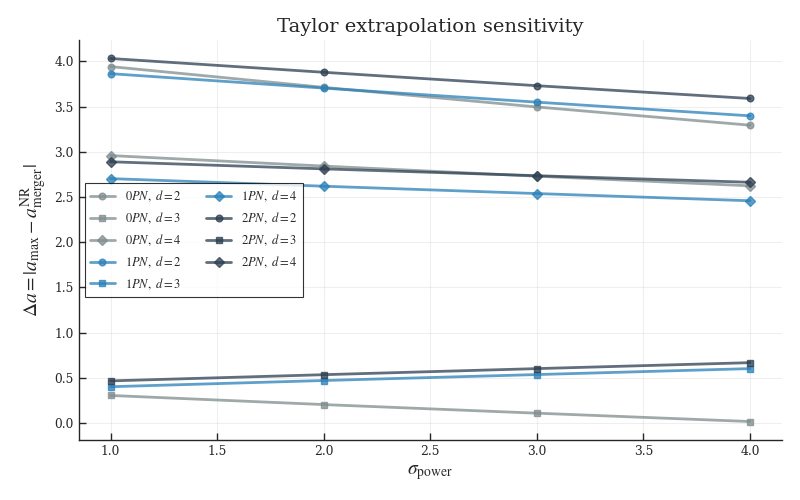

In [185]:
degree_grid = [2, 3, 4]
sigma_power_grid = [1.0, 2.0, 3.0, 4.0]

try:
    m_ref = float(m1 + m2)
except Exception:
    try:
        m_ref = float(m1 + m2)
    except Exception:
        m_ref = 1.0


taylor_inputs_sensitivity = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}


taylor_sensitivity_results = []
taylor_sensitivity_curves = {}

for pn_label, data in taylor_inputs_sensitivity.items():

    for degree in degree_grid:

        for sigma_power in sigma_power_grid:

            key = (pn_label, degree, sigma_power)

            try:
                result_row, curve_dict = run_taylor_entropy_extrapolation(
                    pn_label=pn_label,
                    a_arr=data["a"],
                    M_arr=data["M"],
                    J_arr=data["J"],
                    S_arr=data["S"],
                    m_ref=m_ref,
                    a_merger=a_merger,
                    degree_Ebind=degree,
                    degree_chi=degree,
                    a_extrap_max=15.0,
                    a_extrap_min=1.0,
                    n_extrap=10000,
                    sigma_power=sigma_power
                )

                result_row["degree"] = degree
                result_row["sigma_power"] = sigma_power
                result_row["status"] = "success"
                result_row["error"] = ""

                taylor_sensitivity_results.append(result_row)
                taylor_sensitivity_curves[key] = curve_dict

            except Exception as exc:

                taylor_sensitivity_results.append(
                    {
                        "PN_order": pn_label,
                        "model": f"Taylor degree {degree}",
                        "degree_Ebind": degree,
                        "degree_chi": degree,
                        "degree": degree,
                        "sigma_power": sigma_power,
                        "a_max": np.nan,
                        "S_max": np.nan,
                        "M_at_max": np.nan,
                        "J_at_max": np.nan,
                        "chi_at_max": np.nan,
                        "a_merger_NR": a_merger,
                        "delta_a": np.nan,
                        "cost_Ebind": np.nan,
                        "cost_chi": np.nan,
                        "nfev_Ebind": np.nan,
                        "nfev_chi": np.nan,
                        "flags": "failed",
                        "status": "failed",
                        "error": str(exc)
                    }
                )


taylor_sensitivity_df = pd.DataFrame(taylor_sensitivity_results)

successful_taylor_sensitivity_df = (
    taylor_sensitivity_df[
        taylor_sensitivity_df["status"] == "success"
    ]
    .copy()
)


print("============================================================")
print("TAYLOR SENSITIVITY ANALYSIS")
print("============================================================")

display(
    taylor_sensitivity_df[
        [
            "PN_order",
            "degree",
            "sigma_power",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "flags",
            "status"
        ]
    ]
    .sort_values(
        [
            "PN_order",
            "degree",
            "sigma_power"
        ]
    )
    .reset_index(drop=True)
)


print("============================================================")
print("SUMMARY BY PN ORDER")
print("============================================================")

summary_taylor_sensitivity_df = (
    successful_taylor_sensitivity_df
    .groupby("PN_order")
    .agg(
        n_success=("delta_a", "count"),
        mean_a_max=("a_max", "mean"),
        median_a_max=("a_max", "median"),
        std_a_max=("a_max", "std"),
        min_a_max=("a_max", "min"),
        max_a_max=("a_max", "max"),
        mean_delta_a=("delta_a", "mean"),
        median_delta_a=("delta_a", "median"),
        std_delta_a=("delta_a", "std"),
        min_delta_a=("delta_a", "min"),
        max_delta_a=("delta_a", "max")
    )
    .reset_index()
)

display(summary_taylor_sensitivity_df)


print("============================================================")
print("BEST CONFIGURATION FOR EACH PN ORDER")
print("============================================================")

best_taylor_sensitivity_df = (
    successful_taylor_sensitivity_df
    .sort_values(
        [
            "PN_order",
            "delta_a"
        ]
    )
    .groupby("PN_order")
    .head(1)
    .reset_index(drop=True)
)

display(
    best_taylor_sensitivity_df[
        [
            "PN_order",
            "degree",
            "sigma_power",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "flags"
        ]
    ]
)


print("============================================================")
print("REFERENCE CONFIGURATION: degree = 3, sigma_power = 3")
print("============================================================")

reference_taylor_sensitivity_df = (
    successful_taylor_sensitivity_df[
        (successful_taylor_sensitivity_df["degree"] == 3)
        &
        (successful_taylor_sensitivity_df["sigma_power"] == 3.0)
    ]
    .copy()
)

display(
    reference_taylor_sensitivity_df[
        [
            "PN_order",
            "degree",
            "sigma_power",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "flags"
        ]
    ]
    .reset_index(drop=True)
)


sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

colors = {
    "0PN": "#7f8c8d",
    "1PN": "#2980b9",
    "2PN": "#2c3e50"
}

markers = {
    2: "o",
    3: "s",
    4: "D"
}

fig, ax = plt.subplots(figsize=(8, 5))

for pn_label in ["0PN", "1PN", "2PN"]:

    for degree in degree_grid:

        subset = successful_taylor_sensitivity_df[
            (successful_taylor_sensitivity_df["PN_order"] == pn_label)
            &
            (successful_taylor_sensitivity_df["degree"] == degree)
        ].copy()

        subset = subset.sort_values("sigma_power")

        if len(subset) == 0:
            continue

        ax.plot(
            subset["sigma_power"],
            subset["delta_a"],
            marker=markers[degree],
            lw=2.0,
            color=colors[pn_label],
            alpha=0.75,
            label=fr"${pn_label},\ d={degree}$"
        )

ax.set_xlabel(r"$\sigma_{\rm power}$")
ax.set_ylabel(r"$\Delta a = |a_{\max}-a_{\rm merger}^{\rm NR}|$")
ax.set_title(r"Taylor extrapolation sensitivity")

ax.legend(
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="best",
    ncol=2
)

sns.despine()
plt.tight_layout()
plt.show()